<a href="https://colab.research.google.com/github/Tazin17/pain-intensity-prediction-from-laser-evoked-eeg-responses/blob/main/mathrawala_baseline_exp8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive

# Try to unmount if it's already mounted or partially mounted
try:
  drive.flush_and_unmount()
  print('Drive unmounted.')
except ValueError:
  pass # Drive was not mounted, nothing to unmount

# Ensure the mount point is clean
if os.path.isdir('/content/drive'):
  # Remove all contents of the directory, but not the directory itself
  # This avoids issues if the directory is still seen as a mount point
  for item in os.listdir('/content/drive'):
    item_path = os.path.join('/content/drive', item)
    if os.path.isfile(item_path):
      os.remove(item_path)
    elif os.path.isdir(item_path):
      import shutil
      shutil.rmtree(item_path)
  print('Cleared /content/drive directory.')
else:
  # If the directory doesn't exist, create it
  os.makedirs('/content/drive', exist_ok=True)
  print('Created /content/drive directory.')

# Attempt to mount again
drive.mount('/content/drive', force_remount=True)

Drive not mounted, so nothing to flush and unmount.
Drive unmounted.
Created /content/drive directory.
Mounted at /content/drive


In [ ]:
!pip install pymatreader PyWavelets antropy xgboost tqdm -q

In [ ]:

import os, re, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from tqdm import tqdm

from pymatreader import read_mat
from scipy.signal import welch, coherence, resample_poly
from scipy.stats import skew, kurtosis
import pywt
from antropy import sample_entropy, higuchi_fd

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report
)

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [ ]:
# CHANGE THIS PATH IF NEEDED
EXP8_DIR = "/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer"

OUTPUT_DIR = "/content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("EXP8_DIR exists:", os.path.exists(EXP8_DIR))
print("OUTPUT_DIR:", OUTPUT_DIR)

EXP8_DIR exists: True
OUTPUT_DIR: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE


In [ ]:
def find_set_files(root_dir):
    set_files = []
    for root, dirs, files in os.walk(root_dir):
        for f in files:
            if f.endswith(".set"):
                set_files.append(os.path.join(root, f))
    return sorted(set_files)

def safe_scalar(x, default=np.nan):
    try:
        if isinstance(x, list):
            if len(x) == 0:
                return default
            return safe_scalar(x[0], default)

        arr = np.asarray(x)
        if arr.size == 0:
            return default

        val = arr.flatten()[0]

        if isinstance(val, bytes):
            return val.decode()

        return val
    except Exception:
        return default

def listify(x):
    if isinstance(x, list):
        return x
    if isinstance(x, np.ndarray):
        return list(x.flatten())
    return [x]

def clean_channel_name(ch):
    ch = str(safe_scalar(ch, ch))
    ch = ch.replace("[", "").replace("]", "")
    ch = ch.replace("'", "").replace('"', "")
    ch = ch.replace(" ", "")
    return ch.strip()

def get_subject_id(path):
    m = re.search(r"(sub-\d+)", path)
    return m.group(1) if m else os.path.basename(path).split("_")[0]

def get_channel_labels(chanlocs, nbchan):
    labels = []

    try:
        if isinstance(chanlocs, dict) and "labels" in chanlocs:
            labels = [clean_channel_name(x) for x in listify(chanlocs["labels"])]

        elif isinstance(chanlocs, list):
            for c in chanlocs:
                if isinstance(c, dict) and "labels" in c:
                    labels.append(clean_channel_name(c["labels"]))

    except Exception:
        labels = []

    labels = [x for x in labels if str(x).strip() != ""]

    if len(labels) != nbchan:
        labels = [f"Ch{i+1:03d}" for i in range(nbchan)]

    return labels

def load_eeg_data_from_set(mat, set_path):
    """
    Returns EEG data as channels × time × trials.
    Works when EEG data are inside .set or stored in companion .fdt.
    """
    nbchan = int(safe_scalar(mat["nbchan"]))
    pnts = int(safe_scalar(mat["pnts"]))
    trials = int(safe_scalar(mat["trials"]))

    data = mat.get("data", None)

    if isinstance(data, np.ndarray):
        arr = np.asarray(data)

        if arr.ndim == 3:
            return arr.astype(np.float32)

        if arr.ndim == 2 and arr.shape[0] == nbchan:
            return arr.reshape((nbchan, pnts, trials), order="F").astype(np.float32)

    fdt_name = None

    if isinstance(data, str):
        fdt_name = data
    elif isinstance(data, bytes):
        fdt_name = data.decode()

    datfile = safe_scalar(mat.get("datfile", ""), "")
    if isinstance(datfile, str) and datfile.strip() != "":
        fdt_name = datfile

    if fdt_name is None or str(fdt_name).lower() == "nan" or str(fdt_name).strip() == "":
        fdt_name = os.path.splitext(os.path.basename(set_path))[0] + ".fdt"

    fdt_path = os.path.join(os.path.dirname(set_path), fdt_name)

    if not os.path.exists(fdt_path):
        fdt_path = set_path.replace(".set", ".fdt")

    if not os.path.exists(fdt_path):
        raise FileNotFoundError(f"Missing .fdt file: {fdt_path}")

    raw = np.fromfile(fdt_path, dtype=np.float32)
    expected = nbchan * pnts * trials

    if raw.size != expected:
        raise ValueError(
            f"FDT size mismatch: got {raw.size}, expected {expected}, file={fdt_path}"
        )

    return raw.reshape((nbchan, pnts, trials), order="F").astype(np.float32)

def extract_trial_metadata_from_epoch(mat, n_trials):
    """
    Extracts pain rating, laser power, and event type from EEG.epoch.
    This version matches your working Exp8 notebook.
    """
    pain = [np.nan] * n_trials
    laser = [np.nan] * n_trials
    etype = [np.nan] * n_trials

    epoch = mat.get("epoch", None)

    pain_keys = [
        "eventrating",
        "rating",
        "painrating",
        "eventpainrating",
        "eventpain_rating",
        "pain_rating",
        "stimulus_rating",
        "NRS",
        "nrs"
    ]

    laser_keys = [
        "eventlaser_power",
        "laser_power",
        "laserpower",
        "eventlaserpower",
        "eventlaser"
    ]

    type_keys = [
        "eventtype",
        "type"
    ]

    if epoch is None:
        return pain, laser, etype

    if isinstance(epoch, list):
        for i in range(min(len(epoch), n_trials)):
            ep = epoch[i]

            if not isinstance(ep, dict):
                continue

            for key in pain_keys:
                if key in ep:
                    pain[i] = safe_scalar(ep[key])
                    break

            for key in laser_keys:
                if key in ep:
                    laser[i] = safe_scalar(ep[key])
                    break

            for key in type_keys:
                if key in ep:
                    etype[i] = safe_scalar(ep[key])
                    break

    elif isinstance(epoch, dict):
        for key in pain_keys:
            if key in epoch:
                vals = listify(epoch[key])
                for i in range(min(len(vals), n_trials)):
                    pain[i] = safe_scalar(vals[i])
                break

        for key in laser_keys:
            if key in epoch:
                vals = listify(epoch[key])
                for i in range(min(len(vals), n_trials)):
                    laser[i] = safe_scalar(vals[i])
                break

        for key in type_keys:
            if key in epoch:
                vals = listify(epoch[key])
                for i in range(min(len(vals), n_trials)):
                    etype[i] = safe_scalar(vals[i])
                break

    return pain, laser, etype

In [ ]:
set_files = find_set_files(EXP8_DIR)

print("Total .set files found:", len(set_files))
print(set_files[:5])

Total .set files found: 223
['/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-001_223ByBP.set', '/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-002_223ByBP.set', '/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-003_223ByBP.set', '/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-004_223ByBP.set', '/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-005_223ByBP.set']


In [ ]:
# Cell 6 — Load Exp8 epochs, drop FT9/FT10, create NRS labels

DROP_CHANNELS = ["FT9", "FT10"]

X_list = []
y_list = []
group_list = []

reference_channels = None
sfreq = None
skipped_subjects = []

for set_path in tqdm(set_files, desc="Loading Exp8"):
    sid = get_subject_id(set_path)

    try:
        mat = read_mat(set_path)
        data = load_eeg_data_from_set(mat, set_path)  # channels × time × trials

        nbchan = int(safe_scalar(mat["nbchan"]))
        n_trials = int(safe_scalar(mat["trials"]))
        fs = float(safe_scalar(mat.get("srate", 1000)))

        labels = get_channel_labels(mat.get("chanlocs", []), nbchan)
        labels = [clean_channel_name(ch) for ch in labels]

        # Drop FT9 and FT10 from every subject
        keep_channels = [ch for ch in labels if ch not in DROP_CHANNELS]
        keep_idx = [labels.index(ch) for ch in keep_channels]
        data = data[keep_idx, :, :]

        if reference_channels is None:
            reference_channels = keep_channels
            sfreq = fs
            print("Reference subject:", sid)
            print("Reference channel count after dropping FT9/FT10:", len(reference_channels))

        # Ensure current subject matches reference 62-channel montage
        ch_to_idx = {ch: i for i, ch in enumerate(keep_channels)}
        if not all(ch in ch_to_idx for ch in reference_channels):
            missing = [ch for ch in reference_channels if ch not in ch_to_idx]
            skipped_subjects.append((sid, f"missing reference channels after drop: {missing}"))
            continue

        reorder_idx = [ch_to_idx[ch] for ch in reference_channels]
        data = data[reorder_idx, :, :]

        pain, laser, etype = extract_trial_metadata_from_epoch(mat, n_trials)

        valid_trials = 0

        for tr in range(n_trials):
            rating = safe_scalar(pain[tr])

            if pd.isna(rating):
                continue

            rating = float(rating)

            if 0 <= rating <= 10:
                X_list.append(data[:, :, tr].astype(np.float32))
                y_list.append(1 if rating >= 5 else 0)
                group_list.append(sid)
                valid_trials += 1

        if valid_trials == 0:
            skipped_subjects.append((sid, "no valid pain ratings"))

    except Exception as e:
        skipped_subjects.append((sid, str(e)))
        continue

X_epochs = np.stack(X_list, axis=0)
y = np.array(y_list).astype(int)
groups = np.array(group_list)
ch_names = reference_channels

print("X_epochs:", X_epochs.shape)
print("y:", y.shape)
print("groups:", groups.shape)
print("Channels:", len(ch_names))
print("sfreq:", sfreq)
print("Class counts [low, high]:", np.bincount(y))
print("Subjects:", len(np.unique(groups)))
print("Skipped subjects:", len(skipped_subjects))
print("First skipped:", skipped_subjects[:10])

Loading Exp8:   0%|          | 1/223 [00:00<01:39,  2.23it/s]

Reference subject: sub-001
Reference channel count after dropping FT9/FT10: 62


Loading Exp8: 100%|██████████| 223/223 [07:27<00:00,  2.01s/it]


X_epochs: (6275, 62, 3000)
y: (6275,)
groups: (6275,)
Channels: 62
sfreq: 1000.0
Class counts [low, high]: [2725 3550]
Subjects: 223
Skipped subjects: 0
First skipped: []


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE"
os.makedirs(SAVE_DIR, exist_ok=True)

np.save(os.path.join(SAVE_DIR, "X_epochs_exp8_62ch.npy"), X_epochs)
np.save(os.path.join(SAVE_DIR, "y_exp8.npy"), y)
np.save(os.path.join(SAVE_DIR, "groups_exp8.npy"), groups)

pd.DataFrame({"ch_names": ch_names}).to_csv(
    os.path.join(SAVE_DIR, "ch_names_62ch.csv"), index=False
)

pd.DataFrame({"sfreq": [sfreq]}).to_csv(
    os.path.join(SAVE_DIR, "sfreq.csv"), index=False
)

print("Saved Cell 6 outputs.")

Saved Cell 6 outputs.


In [ ]:
summary_df = pd.DataFrame([{
    "experiment": "EXP8",
    "n_subjects": len(np.unique(groups)),
    "n_epochs_trials": len(y),
    "n_channels": X_epochs.shape[1],
    "n_times": X_epochs.shape[2],
    "sfreq": sfreq,
    "low_pain_count": int(np.sum(y == 0)),
    "high_pain_count": int(np.sum(y == 1)),
    "low_pain_percent": float(np.mean(y == 0) * 100),
    "high_pain_percent": float(np.mean(y == 1) * 100),
}])

display(summary_df)

summary_path = os.path.join(OUTPUT_DIR, "exp8_mathrawala_dataset_summary.csv")
summary_df.to_csv(summary_path, index=False)
print("Saved:", summary_path)

,experiment,n_subjects,n_epochs_trials,n_channels,n_times,sfreq,low_pain_count,high_pain_count,low_pain_percent,high_pain_percent
0,EXP8,223,6275,62,3000,1000.0,2725,3550,43.426295,56.573705


Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/exp8_mathrawala_dataset_summary.csv


In [ ]:
# Cell 8 — Mathrawala-style feature functions, using all common 62 channels

from scipy.signal import welch, coherence
import pywt

EPOCH_TMIN = -1.0
TARGET_FEATURES = 537

bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 90)
}

windows = {
    "full1s": (0.0, 1.0),
    "early": (0.0, 0.160),
    "middle": (0.160, 0.300),
    "late": (0.300, 1.000)
}

# Use all common 62 channels after dropping FT9 and FT10
selected_channels = ch_names
selected_idx = list(range(len(ch_names)))

print("Selected channel count:", len(selected_channels))
print("Selected channels:", selected_channels)

def slice_time(sig, sfreq, start, end):
    s = int((start - EPOCH_TMIN) * sfreq)
    e = int((end - EPOCH_TMIN) * sfreq)
    s = max(0, s)
    e = min(len(sig), e)
    return sig[s:e]

def bandpower(sig, sfreq, fmin, fmax):
    if len(sig) < 16:
        return 0.0
    freqs, psd = welch(sig, fs=sfreq, nperseg=min(256, len(sig)))
    mask = (freqs >= fmin) & (freqs <= fmax)
    if not np.any(mask):
        return 0.0
    return np.trapz(psd[mask], freqs[mask])

def hjorth(sig):
    sig = np.asarray(sig)
    if len(sig) < 3:
        return 0.0, 0.0, 0.0

    d1 = np.diff(sig)
    d2 = np.diff(d1)

    v0 = np.var(sig)
    v1 = np.var(d1)
    v2 = np.var(d2)

    activity = v0
    mobility = np.sqrt(v1 / v0) if v0 > 0 else 0.0
    complexity = np.sqrt(v2 / v1) / mobility if v1 > 0 and mobility > 0 else 0.0

    return activity, mobility, complexity

def spectral_entropy(sig, sfreq):
    if len(sig) < 16:
        return 0.0

    freqs, psd = welch(sig, fs=sfreq, nperseg=min(256, len(sig)))
    total = np.sum(psd)

    if total <= 0:
        return 0.0

    p = psd / total
    p = p[p > 0]

    return -np.sum(p * np.log2(p))

def zero_crossing_rate(sig):
    if len(sig) < 2:
        return 0.0
    return np.mean(np.diff(np.signbit(sig)))

def wavelet_feats(sig):
    try:
        coeffs = pywt.wavedec(sig, "db4", level=4)
        return [np.mean(np.abs(c)) for c in coeffs]
    except Exception:
        return [0.0] * 5

def peak_freq_bandwidth(sig, sfreq, fmin, fmax):
    if len(sig) < 16:
        return 0.0, 0.0

    freqs, psd = welch(sig, fs=sfreq, nperseg=min(256, len(sig)))
    mask = (freqs >= fmin) & (freqs <= fmax)

    if not np.any(mask):
        return 0.0, 0.0

    f = freqs[mask]
    p = psd[mask]

    if np.max(p) <= 0:
        return 0.0, 0.0

    peak = f[np.argmax(p)]
    half = np.max(p) / 2
    above = f[p >= half]
    bw = above[-1] - above[0] if len(above) > 1 else 0.0

    return peak, bw

def fixed_537(feats):
    feats = np.asarray(feats, dtype=float)
    feats = np.nan_to_num(feats, nan=np.nan, posinf=np.nan, neginf=np.nan)

    if len(feats) > TARGET_FEATURES:
        return feats[:TARGET_FEATURES]

    if len(feats) < TARGET_FEATURES:
        return np.pad(
            feats,
            (0, TARGET_FEATURES - len(feats)),
            constant_values=np.nan
        )

    return feats

Selected channel count: 62
Selected channels: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz', 'Oz', 'FC1', 'FC2', 'CP1', 'CP2', 'FC5', 'FC6', 'CP5', 'CP6', 'TP9', 'TP10', 'ECG', 'F1', 'F2', 'C1', 'C2', 'P1', 'P2', 'AF3', 'AF4', 'FC3', 'FC4', 'CP3', 'CP4', 'PO3', 'PO4', 'F5', 'F6', 'C5', 'C6', 'P5', 'P6', 'AF7', 'AF8', 'FT7', 'FT8', 'TP7', 'TP8', 'PO7', 'PO8', 'Fpz', 'CPz', 'POz']


In [ ]:
selected_channels = [ch for ch in ch_names if ch != "ECG"]
selected_idx = [ch_names.index(ch) for ch in selected_channels]

print("Selected channel count:", len(selected_channels))
print("Selected channels:", selected_channels)

Selected channel count: 61
Selected channels: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz', 'Oz', 'FC1', 'FC2', 'CP1', 'CP2', 'FC5', 'FC6', 'CP5', 'CP6', 'TP9', 'TP10', 'F1', 'F2', 'C1', 'C2', 'P1', 'P2', 'AF3', 'AF4', 'FC3', 'FC4', 'CP3', 'CP4', 'PO3', 'PO4', 'F5', 'F6', 'C5', 'C6', 'P5', 'P6', 'AF7', 'AF8', 'FT7', 'FT8', 'TP7', 'TP8', 'PO7', 'PO8', 'Fpz', 'CPz', 'POz']


In [ ]:
def extract_one_epoch(epoch):
    feats = []
    ep = epoch[selected_idx, :]

    for ci, ch in enumerate(selected_channels):
        sig = ep[ci]
        sig1 = slice_time(sig, sfreq, 0.0, 1.0)

        if len(sig1) < 16:
            sig1 = sig

        full_bp = {}

        for wname, (t1, t2) in windows.items():
            sw = slice_time(sig, sfreq, t1, t2)
            if len(sw) < 16:
                sw = sig1

            for bname, (f1, f2) in bands.items():
                bp = bandpower(sw, sfreq, f1, f2)
                feats.append(bp)

                if wname == "full1s":
                    full_bp[bname] = bp

        eps = 1e-12
        feats.extend([
            full_bp.get("gamma", 0) / (full_bp.get("alpha", 0) + eps),
            full_bp.get("delta", 0) / (full_bp.get("theta", 0) + eps),
            full_bp.get("theta", 0) / (full_bp.get("alpha", 0) + eps),
            full_bp.get("beta", 0) / (full_bp.get("alpha", 0) + eps),
            full_bp.get("gamma", 0) / (full_bp.get("beta", 0) + eps)
        ])

        feats.extend([
            np.mean(sig1),
            np.std(sig1),
            skew(sig1),
            kurtosis(sig1),
            zero_crossing_rate(sig1),
            np.ptp(sig1)
        ])

        feats.extend(hjorth(sig1))

        try:
            sampen = sample_entropy(sig1, order=2)
        except Exception:
            sampen = 0.0

        try:
            hfd = higuchi_fd(sig1, kmax=10)
        except Exception:
            hfd = 0.0

        feats.extend([
            spectral_entropy(sig1, sfreq),
            sampen,
            hfd
        ])

        feats.extend(wavelet_feats(sig1))

        for bname, (f1, f2) in bands.items():
            pf, bw = peak_freq_bandwidth(sig1, sfreq, f1, f2)
            feats.extend([pf, bw])

    coherence_pairs = [("C3", "C4"), ("FC1", "FC2")]
    chloc = {ch: i for i, ch in enumerate(selected_channels)}

    for a, b in coherence_pairs:
        if a in chloc and b in chloc:
            s1 = slice_time(ep[chloc[a]], sfreq, 0.0, 1.0)
            s2 = slice_time(ep[chloc[b]], sfreq, 0.0, 1.0)

            if len(s1) >= 16 and len(s2) >= 16:
                f, cxy = coherence(s1, s2, fs=sfreq, nperseg=min(256, len(s1)))
                for bname, (f1, f2) in bands.items():
                    mask = (f >= f1) & (f <= f2)
                    feats.append(np.mean(cxy[mask]) if np.any(mask) else 0.0)
            else:
                feats.extend([0.0] * len(bands))
        else:
            feats.extend([np.nan] * len(bands))

    return fixed_537(feats)

X_math = []

for i in tqdm(range(X_epochs.shape[0]), desc="Extracting Mathrawala-style features"):
    X_math.append(extract_one_epoch(X_epochs[i]))

X_math = np.vstack(X_math)

print("X_math shape:", X_math.shape)
print("Class counts:", np.bincount(y))
print("Subjects:", len(np.unique(groups)))

feature_path = os.path.join(OUTPUT_DIR, "exp8_mathrawala_537_features.npy")
label_path = os.path.join(OUTPUT_DIR, "exp8_mathrawala_labels.npy")
group_path = os.path.join(OUTPUT_DIR, "exp8_mathrawala_groups.npy")

np.save(feature_path, X_math)
np.save(label_path, y)
np.save(group_path, groups)

print("Saved features:", feature_path)

Extracting Mathrawala-style features: 100%|██████████| 6275/6275 [2:51:04<00:00,  1.64s/it]


X_math shape: (6275, 537)
Class counts: [2725 3550]
Subjects: 223
Saved features: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/exp8_mathrawala_537_features.npy


In [ ]:
import os, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from tqdm import tqdm

SAVE_DIR = "/content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE"

X_epochs = np.load(os.path.join(SAVE_DIR, "X_epochs_exp8_62ch.npy"))
y = np.load(os.path.join(SAVE_DIR, "y_exp8.npy"))
groups = np.load(os.path.join(SAVE_DIR, "groups_exp8.npy"), allow_pickle=True)
ch_names = pd.read_csv(os.path.join(SAVE_DIR, "ch_names_62ch.csv"))["ch_names"].tolist()
sfreq = float(pd.read_csv(os.path.join(SAVE_DIR, "sfreq.csv"))["sfreq"].iloc[0])

# Remove ECG if present
if "ECG" in ch_names:
    ecg_idx = ch_names.index("ECG")
    X_epochs = np.delete(X_epochs, ecg_idx, axis=1)
    ch_names = [ch for ch in ch_names if ch != "ECG"]

print("X_epochs:", X_epochs.shape)
print("Class counts:", np.bincount(y))
print("Subjects:", len(np.unique(groups)))
print("Channels:", len(ch_names))

X_epochs: (6275, 61, 3000)
Class counts: [2725 3550]
Subjects: 223
Channels: 61


In [ ]:
!pip install PyWavelets antropy xgboost -q

import pywt
from scipy.signal import welch, coherence
from scipy.stats import skew, kurtosis
from antropy import sample_entropy, higuchi_fd

EPOCH_TMIN = -1.0

BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 90)
}

WINDOWS = {
    "full1s": (0.0, 1.0),
    "early": (0.0, 0.160),
    "middle": (0.160, 0.300),
    "late": (0.300, 1.000)
}

# Paper-supported pain-relevant electrodes from feature importance + midline/contralateral sites
CORE_CHANNELS = ["C4", "Cz", "Fz", "CPz", "FC2", "FC1", "Pz", "C3", "C2", "C1"]

missing = [ch for ch in CORE_CHANNELS if ch not in ch_names]
if missing:
    raise ValueError(f"Missing required core channels: {missing}")

core_idx = [ch_names.index(ch) for ch in CORE_CHANNELS]

def slice_time(sig, start, end):
    s = int((start - EPOCH_TMIN) * sfreq)
    e = int((end - EPOCH_TMIN) * sfreq)
    return sig[max(0, s):min(len(sig), e)]

def bandpower(sig, fmin, fmax):
    if len(sig) < 16:
        return 0.0
    freqs, psd = welch(sig, fs=sfreq, nperseg=min(256, len(sig)))
    mask = (freqs >= fmin) & (freqs <= fmax)
    return np.trapz(psd[mask], freqs[mask]) if np.any(mask) else 0.0

def hjorth(sig):
    d1, d2 = np.diff(sig), np.diff(np.diff(sig))
    v0, v1, v2 = np.var(sig), np.var(d1), np.var(d2)
    activity = v0
    mobility = np.sqrt(v1 / v0) if v0 > 0 else 0.0
    complexity = np.sqrt(v2 / v1) / mobility if v1 > 0 and mobility > 0 else 0.0
    return [activity, mobility, complexity]

def spectral_entropy(sig):
    freqs, psd = welch(sig, fs=sfreq, nperseg=min(256, len(sig)))
    total = np.sum(psd)
    if total <= 0:
        return 0.0
    p = psd / total
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

def wavelet_features(sig):
    try:
        coeffs = pywt.wavedec(sig, "db4", level=4)
        return [np.mean(np.abs(c)) for c in coeffs]  # 5 values
    except Exception:
        return [0.0] * 5

def peak_freq_bw(sig, fmin, fmax):
    freqs, psd = welch(sig, fs=sfreq, nperseg=min(256, len(sig)))
    mask = (freqs >= fmin) & (freqs <= fmax)
    if not np.any(mask):
        return [0.0, 0.0]
    f, p = freqs[mask], psd[mask]
    if np.max(p) <= 0:
        return [0.0, 0.0]
    peak = f[np.argmax(p)]
    half = np.max(p) / 2
    above = f[p >= half]
    bw = above[-1] - above[0] if len(above) > 1 else 0.0
    return [peak, bw]

def zcr(sig):
    return np.mean(np.diff(np.signbit(sig))) if len(sig) > 1 else 0.0

def extract_537(epoch):
    feats = []
    ep = epoch[core_idx, :]

    # 10 channels × 52 features = 520
    for ci, ch in enumerate(CORE_CHANNELS):
        sig = ep[ci]
        sig1 = slice_time(sig, 0.0, 1.0)

        full_bp = {}

        # 4 windows × 5 bands = 20
        for wname, (a, b) in WINDOWS.items():
            sw = slice_time(sig, a, b)
            if len(sw) < 16:
                sw = sig1
            for band, (f1, f2) in BANDS.items():
                bp = bandpower(sw, f1, f2)
                feats.append(bp)
                if wname == "full1s":
                    full_bp[band] = bp

        eps = 1e-12

        # 5 ratios
        feats.extend([
            full_bp["gamma"] / (full_bp["alpha"] + eps),
            full_bp["delta"] / (full_bp["theta"] + eps),
            full_bp["theta"] / (full_bp["alpha"] + eps),
            full_bp["beta"] / (full_bp["alpha"] + eps),
            full_bp["gamma"] / (full_bp["beta"] + eps)
        ])

        # 6 time-domain statistics
        feats.extend([
            np.mean(sig1),
            np.std(sig1),
            skew(sig1),
            kurtosis(sig1),
            zcr(sig1),
            np.ptp(sig1)
        ])

        # 3 Hjorth
        feats.extend(hjorth(sig1))

        # 3 irregularity features
        try:
            sampen = sample_entropy(sig1, order=2)
        except Exception:
            sampen = 0.0

        try:
            hfd = higuchi_fd(sig1, kmax=10)
        except Exception:
            hfd = 0.0

        feats.extend([
            spectral_entropy(sig1),
            sampen,
            hfd
        ])

        # 5 wavelet features
        feats.extend(wavelet_features(sig1))

        # 5 bands × 2 peak metrics = 10
        for band, (f1, f2) in BANDS.items():
            feats.extend(peak_freq_bw(sig1, f1, f2))

    # 2 homologous pairs × 5 bands = 10
    pair_list = [("C3", "C4"), ("FC1", "FC2")]
    chloc = {ch: i for i, ch in enumerate(CORE_CHANNELS)}

    for a, b in pair_list:
        s1 = slice_time(ep[chloc[a]], 0.0, 1.0)
        s2 = slice_time(ep[chloc[b]], 0.0, 1.0)
        f, cxy = coherence(s1, s2, fs=sfreq, nperseg=min(256, len(s1)))
        for band, (f1, f2) in BANDS.items():
            mask = (f >= f1) & (f <= f2)
            feats.append(np.mean(cxy[mask]) if np.any(mask) else 0.0)

    # 7 global features = total 537
    global_sig = np.mean(ep, axis=0)
    g1 = slice_time(global_sig, 0.0, 1.0)

    g_delta = bandpower(g1, 1, 4)
    g_theta = bandpower(g1, 4, 8)
    g_alpha = bandpower(g1, 8, 13)
    g_beta  = bandpower(g1, 13, 30)
    g_gamma = bandpower(g1, 30, 90)

    eps = 1e-12
    feats.extend([
        g_alpha,
        g_theta,
        g_beta,
        g_gamma,
        g_theta / (g_alpha + eps),
        g_gamma / (g_alpha + eps),
        np.ptp(g1)
    ])

    if len(feats) != 537:
        raise ValueError(f"Feature length is {len(feats)}, expected 537")

    return np.asarray(feats, dtype=np.float32)

# Test one epoch
test_vec = extract_537(X_epochs[0])
print("Test feature length:", len(test_vec))

Test feature length: 537


In [ ]:
X_math_faithful = []

for i in tqdm(range(X_epochs.shape[0]), desc="Extracting Mathrawala-faithful 537 features"):
    X_math_faithful.append(extract_537(X_epochs[i]))

X_math_faithful = np.vstack(X_math_faithful)

print("Shape:", X_math_faithful.shape)
print("Class counts:", np.bincount(y))
print("Subjects:", len(np.unique(groups)))

np.save(os.path.join(SAVE_DIR, "exp8_mathrawala_faithful_537_features.npy"), X_math_faithful)
np.save(os.path.join(SAVE_DIR, "exp8_mathrawala_faithful_labels.npy"), y)
np.save(os.path.join(SAVE_DIR, "exp8_mathrawala_faithful_groups.npy"), groups)

print("Saved faithful reconstructed features.")

Extracting Mathrawala-faithful 537 features: 100%|██████████| 6275/6275 [30:25<00:00,  3.44it/s]

Shape: (6275, 537)
Class counts: [2725 3550]
Subjects: 223
Saved faithful reconstructed features.


In [ ]:
feature_names = []

for ch in CORE_CHANNELS:
    for wname in WINDOWS.keys():
        for band in BANDS.keys():
            feature_names.append(f"{ch}__{wname}__bp_{band}")

    feature_names += [
        f"{ch}__ratio_gamma_alpha",
        f"{ch}__ratio_delta_theta",
        f"{ch}__ratio_theta_alpha",
        f"{ch}__ratio_beta_alpha",
        f"{ch}__ratio_gamma_beta",
        f"{ch}__mean",
        f"{ch}__std",
        f"{ch}__skew",
        f"{ch}__kurtosis",
        f"{ch}__zero_crossing_rate",
        f"{ch}__peak_to_peak",
        f"{ch}__hjorth_activity",
        f"{ch}__hjorth_mobility",
        f"{ch}__hjorth_complexity",
        f"{ch}__spectral_entropy",
        f"{ch}__sample_entropy",
        f"{ch}__higuchi_fd",
    ]

    for level in range(5):
        feature_names.append(f"{ch}__wavelet_db4_level_{level}_mean_abs")

    for band in BANDS.keys():
        feature_names.append(f"{ch}__{band}_peak_frequency")
        feature_names.append(f"{ch}__{band}_bandwidth_3db")

for pair in [("C3", "C4"), ("FC1", "FC2")]:
    for band in BANDS.keys():
        feature_names.append(f"coherence_{pair[0]}_{pair[1]}__{band}")

feature_names += [
    "GLOBAL__alpha_power",
    "GLOBAL__theta_power",
    "GLOBAL__beta_power",
    "GLOBAL__gamma_power",
    "GLOBAL__theta_alpha_ratio",
    "GLOBAL__gamma_alpha_ratio",
    "GLOBAL__peak_to_peak"
]

print("Total feature names:", len(feature_names))
pd.DataFrame({"feature": feature_names}).to_csv(
    os.path.join(SAVE_DIR, "mathrawala_faithful_537_feature_names.csv"),
    index=False
)
display(pd.DataFrame({"feature": feature_names}).head(60))
display(pd.DataFrame({"feature": feature_names}).head(537))

Total feature names: 537


,feature
0,C4__full1s__bp_delta
1,C4__full1s__bp_theta
2,C4__full1s__bp_alpha
3,C4__full1s__bp_beta
4,C4__full1s__bp_gamma
5,C4__early__bp_delta
6,C4__early__bp_theta
7,C4__early__bp_alpha
8,C4__early__bp_beta
9,C4__early__bp_gamma


,feature
0,C4__full1s__bp_delta
1,C4__full1s__bp_theta
2,C4__full1s__bp_alpha
3,C4__full1s__bp_beta
4,C4__full1s__bp_gamma
...,...
532,GLOBAL__beta_power
533,GLOBAL__gamma_power
534,GLOBAL__theta_alpha_ratio
535,GLOBAL__gamma_alpha_ratio


In [ ]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

models = {
    "SVM_RBF": SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, class_weight="balanced"),
    "KNeighbors": KNeighborsClassifier(n_neighbors=5),
    "RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                             subsample=0.9, colsample_bytree=0.9,
                             eval_metric="logloss", random_state=42, n_jobs=-1),
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "LinearDiscriminant": LinearDiscriminantAnalysis(),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "GaussianNB": GaussianNB(),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
}

def bootstrap_ci_acc(y_true, y_pred, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    scores = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        scores.append(accuracy_score(y_true[idx], y_pred[idx]))
    return np.percentile(scores, [2.5, 97.5])

def evaluate_loso(name, clf, X, y, groups):
    logo = LeaveOneGroupOut()
    y_true_all, y_pred_all, y_prob_all = [], [], []
    fold_acc, infer_times = [], []

    for train_idx, test_idx in tqdm(logo.split(X, y, groups), total=len(np.unique(groups)), desc=name):
        Xtr, Xte = X[train_idx], X[test_idx]
        ytr, yte = y[train_idx].astype(int), y[test_idx].astype(int)

        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler()),
            ("clf", clf)
        ])

        pipe.fit(Xtr, ytr)

        t0 = time.perf_counter()
        yp = pipe.predict(Xte)
        infer_times.append((time.perf_counter() - t0) / len(Xte) * 1000)

        if hasattr(pipe.named_steps["clf"], "predict_proba"):
            yp_prob = pipe.predict_proba(Xte)[:, 1]
        else:
            yp_prob = yp.astype(float)

        y_true_all.extend(yte)
        y_pred_all.extend(yp)
        y_prob_all.extend(yp_prob)
        fold_acc.append(accuracy_score(yte, yp))

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)
    y_prob_all = np.array(y_prob_all)

    ci_low, ci_high = bootstrap_ci_acc(y_true_all, y_pred_all)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true_all, y_pred_all),
        "F1": f1_score(y_true_all, y_pred_all, zero_division=0),
        "Precision": precision_score(y_true_all, y_pred_all, zero_division=0),
        "Recall": recall_score(y_true_all, y_pred_all, zero_division=0),
        "AUC": roc_auc_score(y_true_all, y_prob_all),
        "Mean_Fold_Accuracy": np.mean(fold_acc),
        "Std_Fold_Accuracy": np.std(fold_acc),
        "Inference_ms_per_epoch": np.mean(infer_times),
        "Bootstrap_CI_Low": ci_low,
        "Bootstrap_CI_High": ci_high,
        "Confusion_Matrix": confusion_matrix(y_true_all, y_pred_all)
    }

In [ ]:
# results = []
# confusions = {}

# for name, clf in models.items():
#     print("\nRunning:", name)
#     res = evaluate_loso(name, clf, X_math_faithful, y, groups)
#     confusions[name] = res.pop("Confusion_Matrix")
#     results.append(res)

# results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
# display(results_df)

# results_path = os.path.join(SAVE_DIR, "exp8_mathrawala_faithful_baseline_results.csv")
# results_df.to_csv(results_path, index=False)

# for name, cm in confusions.items():
#     pd.DataFrame(
#         cm,
#         index=["True_Low", "True_High"],
#         columns=["Pred_Low", "Pred_High"]
#     ).to_csv(os.path.join(SAVE_DIR, f"faithful_confusion_{name}.csv"))

# print("Saved results:", results_path)

In [ ]:
import os, time, numpy as np, pandas as pd
from tqdm import tqdm

SAVE_DIR = "/content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE"

X = np.load(os.path.join(SAVE_DIR, "exp8_mathrawala_faithful_537_features.npy"))
y = np.load(os.path.join(SAVE_DIR, "exp8_mathrawala_faithful_labels.npy"))
groups = np.load(os.path.join(SAVE_DIR, "exp8_mathrawala_faithful_groups.npy"), allow_pickle=True)

print(X.shape, y.shape, groups.shape)
print(np.bincount(y), len(np.unique(groups)))

(6275, 537) (6275,) (6275,)
[2725 3550] 223


In [ ]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
import joblib

def evaluate_one_model(name, clf, X, y, groups, save_dir):
    logo = LeaveOneGroupOut()

    y_true_all, y_pred_all, y_score_all = [], [], []
    fold_rows = []

    result_file = os.path.join(save_dir, f"partial_folds_{name}.csv")

    for fold, (train_idx, test_idx) in enumerate(tqdm(logo.split(X, y, groups), total=len(np.unique(groups)), desc=name), 1):
        test_subject = groups[test_idx][0]

        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler()),
            ("clf", clf)
        ])

        Xtr, Xte = X[train_idx], X[test_idx]
        ytr, yte = y[train_idx].astype(int), y[test_idx].astype(int)

        t0 = time.perf_counter()
        pipe.fit(Xtr, ytr)
        train_time = time.perf_counter() - t0

        t1 = time.perf_counter()
        yp = pipe.predict(Xte)
        infer_ms = (time.perf_counter() - t1) / len(Xte) * 1000

        if hasattr(pipe.named_steps["clf"], "predict_proba"):
            yscore = pipe.predict_proba(Xte)[:, 1]
        elif hasattr(pipe.named_steps["clf"], "decision_function"):
            yscore = pipe.decision_function(Xte)
        else:
            yscore = yp.astype(float)

        y_true_all.extend(yte)
        y_pred_all.extend(yp)
        y_score_all.extend(yscore)

        fold_rows.append({
            "fold": fold,
            "test_subject": test_subject,
            "n_test": len(test_idx),
            "accuracy": accuracy_score(yte, yp),
            "f1": f1_score(yte, yp, zero_division=0),
            "precision": precision_score(yte, yp, zero_division=0),
            "recall": recall_score(yte, yp, zero_division=0),
            "train_time_sec": train_time,
            "inference_ms_per_epoch": infer_ms
        })

        # save after every subject/fold
        pd.DataFrame(fold_rows).to_csv(result_file, index=False)

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)
    y_score_all = np.array(y_score_all)

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_true_all, y_pred_all),
        "F1": f1_score(y_true_all, y_pred_all, zero_division=0),
        "Precision": precision_score(y_true_all, y_pred_all, zero_division=0),
        "Recall": recall_score(y_true_all, y_pred_all, zero_divion=0) if False else recall_score(y_true_all, y_pred_all, zero_division=0),
        "AUC": roc_auc_score(y_true_all, y_score_all),
        "Mean_Fold_Accuracy": pd.DataFrame(fold_rows)["accuracy"].mean(),
        "Std_Fold_Accuracy": pd.DataFrame(fold_rows)["accuracy"].std(),
        "Mean_Inference_ms_per_epoch": pd.DataFrame(fold_rows)["inference_ms_per_epoch"].mean()
    }

    result_df = pd.DataFrame([result])
    result_df.to_csv(os.path.join(save_dir, f"final_result_{name}.csv"), index=False)

    cm = confusion_matrix(y_true_all, y_pred_all)
    pd.DataFrame(cm, index=["True_Low", "True_High"], columns=["Pred_Low", "Pred_High"]).to_csv(
        os.path.join(save_dir, f"confusion_{name}.csv")
    )

    print(result_df)
    print(cm)

    return result_df, cm

In [ ]:
from sklearn.svm import SVC

svm_fast = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=False,
    class_weight="balanced",
    cache_size=2000
)

svm_result, svm_cm = evaluate_one_model(
    "SVM_RBF_fast",
    svm_fast,
    X, y, groups,
    SAVE_DIR
)

SVM_RBF_fast: 100%|██████████| 223/223 [1:05:17<00:00, 17.57s/it]

          Model  Accuracy        F1  Precision    Recall       AUC  \
0  SVM_RBF_fast  0.603825  0.626727   0.671061  0.587887  0.644593   

   Mean_Fold_Accuracy  Std_Fold_Accuracy  Mean_Inference_ms_per_epoch  
0            0.603678           0.179576                     2.868618  
[[1702 1023]
 [1463 2087]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_result, rf_cm = evaluate_one_model("RandomForest", rf, X, y, groups, SAVE_DIR)

RandomForest: 100%|██████████| 223/223 [1:12:56<00:00, 19.63s/it]

          Model  Accuracy       F1  Precision    Recall       AUC  \
0  RandomForest  0.611793  0.68306   0.634671  0.739437  0.651004   

   Mean_Fold_Accuracy  Std_Fold_Accuracy  Mean_Inference_ms_per_epoch  
0            0.611521           0.183453                     2.322789  
[[1214 1511]
 [ 925 2625]]


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

xgb_result, xgb_cm = evaluate_one_model("XGBoost", xgb, X, y, groups, SAVE_DIR)

XGBoost: 100%|██████████| 223/223 [19:04<00:00,  5.13s/it]

     Model  Accuracy        F1  Precision    Recall       AUC  \
0  XGBoost  0.603028  0.663242    0.63764  0.690986  0.650118   

   Mean_Fold_Accuracy  Std_Fold_Accuracy  Mean_Inference_ms_per_epoch  
0            0.603121           0.162852                     0.113415  
[[1331 1394]
 [1097 2453]]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier

fast_models = {
    "KNeighbors": KNeighborsClassifier(n_neighbors=5),
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "LinearDiscriminant": LinearDiscriminantAnalysis(),
    "GaussianNB": GaussianNB(),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
}

for name, model in fast_models.items():
    evaluate_one_model(name, model, X, y, groups, SAVE_DIR)

KNeighbors: 100%|██████████| 223/223 [00:24<00:00,  8.98it/s]


        Model  Accuracy        F1  Precision    Recall       AUC  \
0  KNeighbors  0.562072  0.630844   0.602979  0.661408  0.567053   

   Mean_Fold_Accuracy  Std_Fold_Accuracy  Mean_Inference_ms_per_epoch  
0            0.561599           0.129946                     0.488952  
[[1179 1546]
 [1202 2348]]


LogisticRegression: 100%|██████████| 223/223 [10:14<00:00,  2.75s/it]


                Model  Accuracy        F1  Precision    Recall       AUC  \
0  LogisticRegression  0.596016  0.622487   0.660348  0.588732  0.632732   

   Mean_Fold_Accuracy  Std_Fold_Accuracy  Mean_Inference_ms_per_epoch  
0            0.596396           0.159498                     0.114627  
[[1650 1075]
 [1460 2090]]


LinearDiscriminant: 100%|██████████| 223/223 [01:50<00:00,  2.02it/s]


...

        Model  Accuracy        F1  Precision    Recall       AUC  \
0  GaussianNB  0.581195  0.561708   0.688471  0.474366  0.631655   

   Mean_Fold_Accuracy  Std_Fold_Accuracy  Mean_Inference_ms_per_epoch  
0            0.581095           0.219533                      0.05232  
[[1963  762]
 [1866 1684]]


GradientBoosting: 100%|██████████| 223/223 [5:02:39<00:00, 81.43s/it]


              Model  Accuracy        F1  Precision    Recall       AUC  \
0  GradientBoosting  0.608287  0.672529   0.638018  0.710986  0.650836   

   Mean_Fold_Accuracy  Std_Fold_Accuracy  Mean_Inference_ms_per_epoch  
0            0.608123           0.168163                     0.062485  
[[1293 1432]
 [1026 2524]]


ExtraTrees: 100%|██████████| 223/223 [23:09<00:00,  6.23s/it]

        Model  Accuracy       F1  Precision    Recall       AUC  \
0  ExtraTrees  0.611315  0.68337   0.633759  0.741408  0.654865   

   Mean_Fold_Accuracy  Std_Fold_Accuracy  Mean_Inference_ms_per_epoch  
0            0.610615           0.194393                     2.435956  
[[1204 1521]
 [ 918 2632]]


In [ ]:
import glob
import os
import pandas as pd

files = glob.glob(os.path.join(SAVE_DIR, "final_result_*.csv"))

all_results = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Exclude ExtraTrees
all_results = all_results[~all_results["Model"].str.contains("ExtraTrees", case=False, na=False)]

all_results = all_results.sort_values("Accuracy", ascending=False).reset_index(drop=True)

display(all_results)

save_path = os.path.join(SAVE_DIR, "combined_mathrawala_faithful_results_no_extratrees.csv")
all_results.to_csv(save_path, index=False)

print("Saved:", save_path)

,Model,Accuracy,F1,Precision,Recall,AUC,Mean_Fold_Accuracy,Std_Fold_Accuracy,Mean_Inference_ms_per_epoch
0,RandomForest,0.611793,0.683060,0.634671,0.739437,0.651004,0.611521,0.183453,2.322789
1,GradientBoosting,0.608287,0.672529,0.638018,0.710986,0.650836,0.608123,0.168163,0.062485
2,SVM_RBF_fast,0.603825,0.626727,0.671061,0.587887,0.644593,0.603678,0.179576,2.868618
3,LinearDiscriminant,0.603506,0.664871,0.637068,0.695211,0.632281,0.604126,0.154286,0.057015
4,XGBoost,0.603028,0.663242,0.637640,0.690986,0.650118,0.603121,0.162852,0.113415
5,LogisticRegression,0.596016,0.622487,0.660348,0.588732,0.632732,0.596396,0.159498,0.114627
6,GaussianNB,0.581195,0.561708,0.688471,0.474366,0.631655,0.581095,0.219533,0.052320
7,KNeighbors,0.562072,0.630844,0.602979,0.661408,0.567053,0.561599,0.129946,0.488952


Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/combined_mathrawala_faithful_results_no_extratrees.csv


,Model,Accuracy,F1,Precision,Recall,AUC,Mean_Fold_Accuracy,Std_Fold_Accuracy,Mean_Inference_ms_per_epoch
0,Random Forest,0.611793,0.683060,0.634671,0.739437,0.651004,0.611521,0.183453,2.322789
1,Gradient Boosting,0.608287,0.672529,0.638018,0.710986,0.650836,0.608123,0.168163,0.062485
2,SVM-RBF,0.603825,0.626727,0.671061,0.587887,0.644593,0.603678,0.179576,2.868618
3,LDA,0.603506,0.664871,0.637068,0.695211,0.632281,0.604126,0.154286,0.057015
4,XGBoost,0.603028,0.663242,0.637640,0.690986,0.650118,0.603121,0.162852,0.113415
5,Logistic Regression,0.596016,0.622487,0.660348,0.588732,0.632732,0.596396,0.159498,0.114627
6,Gaussian NB,0.581195,0.561708,0.688471,0.474366,0.631655,0.581095,0.219533,0.052320
7,KNN,0.562072,0.630844,0.602979,0.661408,0.567053,0.561599,0.129946,0.488952


Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/premium_figures_mathrawala/fig1_performance_accuracy_f1_auc.png
Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/premium_figures_mathrawala/fig1_performance_accuracy_f1_auc.pdf
Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/premium_figures_mathrawala/fig1_performance_accuracy_f1_auc.svg


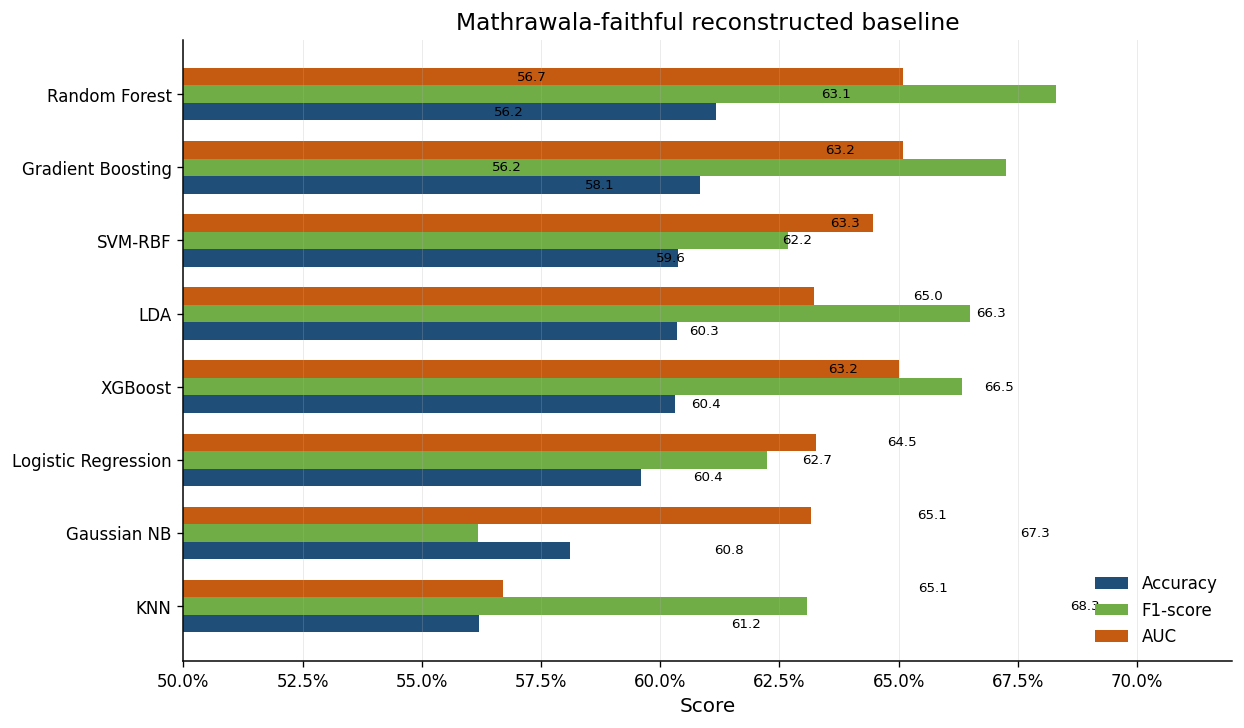

Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/premium_figures_mathrawala/fig2_accuracy_ranking.png
Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/premium_figures_mathrawala/fig2_accuracy_ranking.pdf
Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/premium_figures_mathrawala/fig2_accuracy_ranking.svg


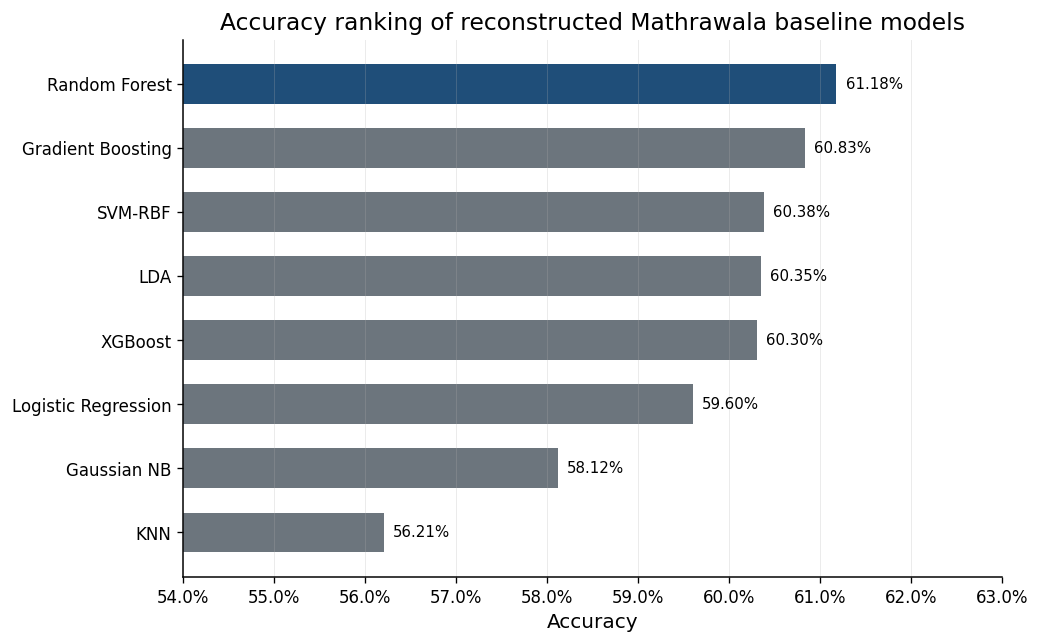

Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/premium_figures_mathrawala/fig3_precision_recall_scatter.png
Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/premium_figures_mathrawala/fig3_precision_recall_scatter.pdf
Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/premium_figures_mathrawala/fig3_precision_recall_scatter.svg


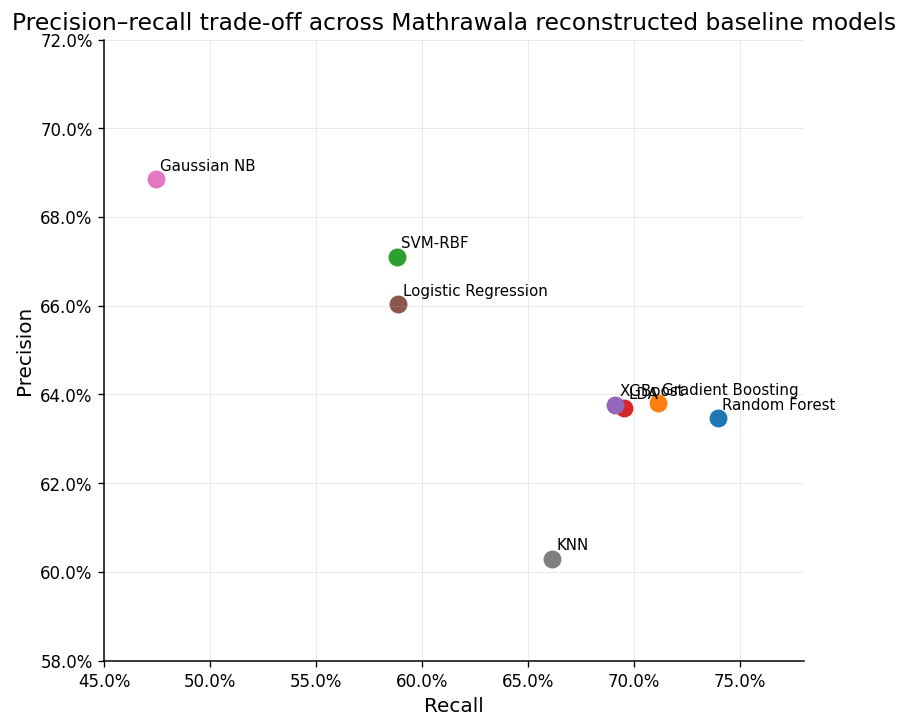

Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/premium_figures_mathrawala/fig4_top_models_radar.png
Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/premium_figures_mathrawala/fig4_top_models_radar.pdf
Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/premium_figures_mathrawala/fig4_top_models_radar.svg


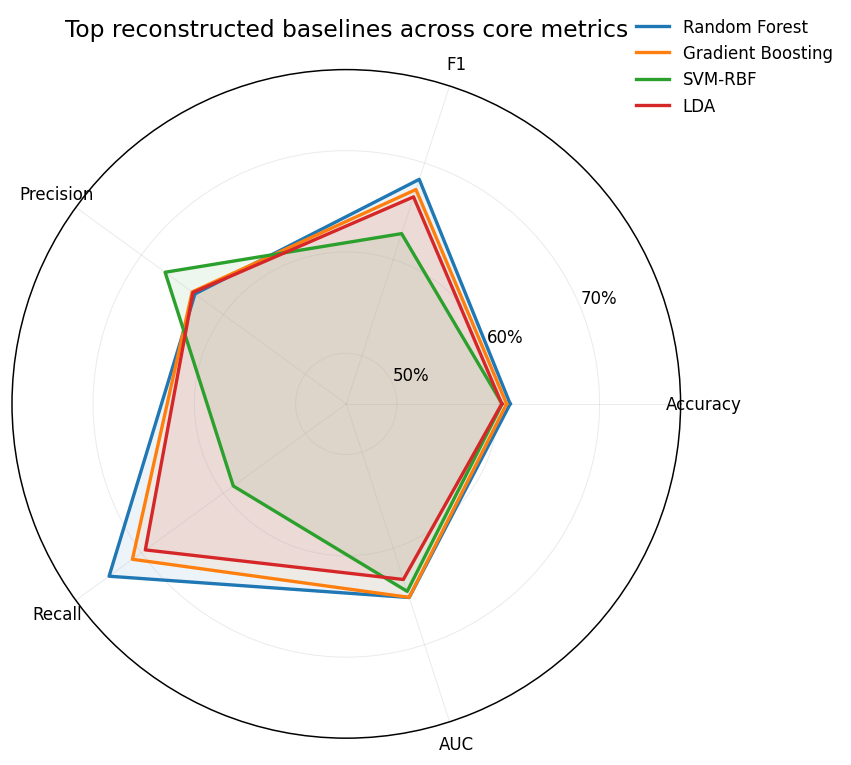

Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/premium_figures_mathrawala/fig5_inference_speed.png
Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/premium_figures_mathrawala/fig5_inference_speed.pdf
Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/premium_figures_mathrawala/fig5_inference_speed.svg


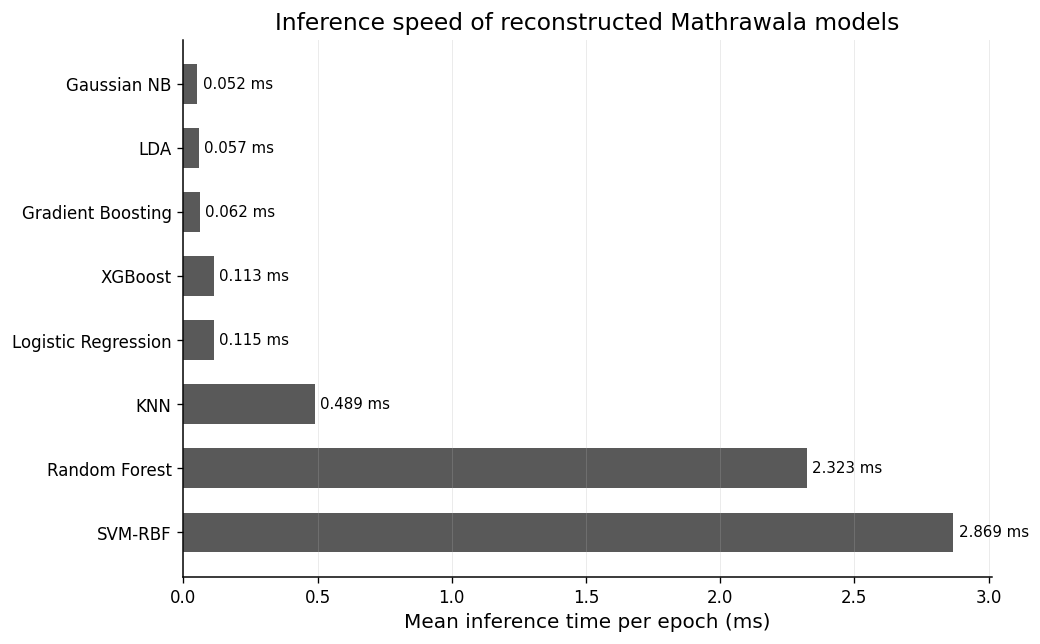

Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/premium_figures_mathrawala/fig6_best_model_confusion_matrix.png
Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/premium_figures_mathrawala/fig6_best_model_confusion_matrix.pdf
Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/premium_figures_mathrawala/fig6_best_model_confusion_matrix.svg


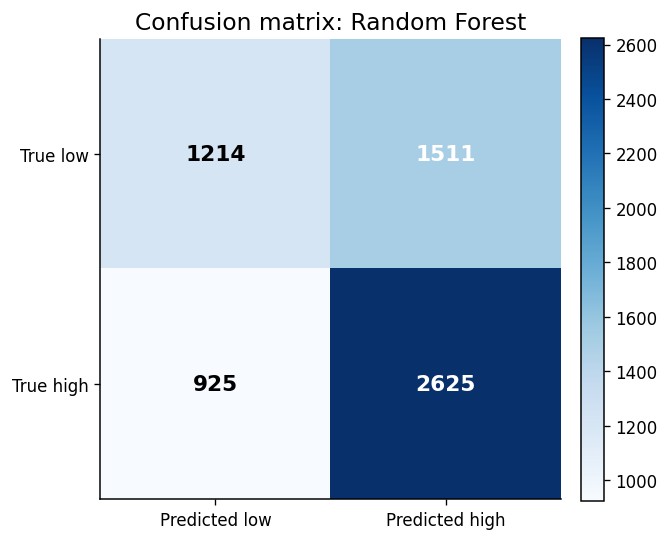

,Model,Accuracy,F1,Precision,Recall,AUC,Mean_Fold_Accuracy,Std_Fold_Accuracy,Mean_Inference_ms_per_epoch
0,Random Forest,0.611793,0.683060,0.634671,0.739437,0.651004,0.611521,0.183453,2.322789
1,Gradient Boosting,0.608287,0.672529,0.638018,0.710986,0.650836,0.608123,0.168163,0.062485
2,SVM-RBF,0.603825,0.626727,0.671061,0.587887,0.644593,0.603678,0.179576,2.868618
3,LDA,0.603506,0.664871,0.637068,0.695211,0.632281,0.604126,0.154286,0.057015
4,XGBoost,0.603028,0.663242,0.637640,0.690986,0.650118,0.603121,0.162852,0.113415
5,Logistic Regression,0.596016,0.622487,0.660348,0.588732,0.632732,0.596396,0.159498,0.114627
6,Gaussian NB,0.581195,0.561708,0.688471,0.474366,0.631655,0.581095,0.219533,0.052320
7,KNN,0.562072,0.630844,0.602979,0.661408,0.567053,0.561599,0.129946,0.488952


All premium figures saved in: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/premium_figures_mathrawala


In [ ]:
# ============================================================
# visualizations for Mathrawala models
# ============================================================

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import PercentFormatter
from sklearn.metrics import ConfusionMatrixDisplay

SAVE_DIR = "/content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE"
FIG_DIR = os.path.join(SAVE_DIR, "premium_figures_mathrawala")
os.makedirs(FIG_DIR, exist_ok=True)

# -----------------------------
# 1. Load and clean results
# -----------------------------
files = glob.glob(os.path.join(SAVE_DIR, "final_result_*.csv"))
results_df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Exclude ExtraTrees
results_df = results_df[~results_df["Model"].str.contains("ExtraTrees", case=False, na=False)].copy()

name_map = {
    "SVM_RBF_fast": "SVM-RBF",
    "KNeighbors": "KNN",
    "RandomForest": "Random Forest",
    "XGBoost": "XGBoost",
    "LogisticRegression": "Logistic Regression",
    "LinearDiscriminant": "LDA",
    "GaussianNB": "Gaussian NB",
    "GradientBoosting": "Gradient Boosting"
}

results_df["Model"] = results_df["Model"].replace(name_map)

# Keep only Mathrawala-reported models
order_models = [
    "Random Forest",
    "Gradient Boosting",
    "LDA",
    "XGBoost",
    "SVM-RBF",
    "Logistic Regression",
    "Gaussian NB",
    "KNN"
]

results_df = results_df[results_df["Model"].isin(order_models)].copy()
results_df = results_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)

display(results_df)

# -----------------------------
# 2. Premium style settings
# -----------------------------
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.9,
    "grid.linewidth": 0.6,
    "grid.alpha": 0.25,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

def save_figure(fig, name):
    png = os.path.join(FIG_DIR, f"{name}.png")
    pdf = os.path.join(FIG_DIR, f"{name}.pdf")
    svg = os.path.join(FIG_DIR, f"{name}.svg")
    fig.savefig(png, bbox_inches="tight", dpi=600)
    fig.savefig(pdf, bbox_inches="tight")
    fig.savefig(svg, bbox_inches="tight")
    print("Saved:", png)
    print("Saved:", pdf)
    print("Saved:", svg)

# -----------------------------
# 3. Figure 1: Main performance comparison
# -----------------------------
metrics = ["Accuracy", "F1", "AUC"]
plot_df = results_df.sort_values("Accuracy", ascending=True)

fig, ax = plt.subplots(figsize=(10.5, 6.2))

y_pos = np.arange(len(plot_df))
height = 0.24

colors = ["#1f4e79", "#70ad47", "#c55a11"]

ax.barh(y_pos - height, plot_df["Accuracy"], height=height, label="Accuracy", color=colors[0])
ax.barh(y_pos, plot_df["F1"], height=height, label="F1-score", color=colors[1])
ax.barh(y_pos + height, plot_df["AUC"], height=height, label="AUC", color=colors[2])

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["Model"])
ax.set_xlim(0.50, 0.72)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_xlabel("Score")
ax.set_title("Mathrawala-faithful reconstructed baseline")
ax.grid(axis="x")
ax.legend(frameon=False, loc="lower right")

for i, row in plot_df.iterrows():
    xpos = row["Accuracy"]
    ax.text(xpos + 0.003, y_pos[i] - height, f"{xpos*100:.1f}", va="center", fontsize=8)
    xpos = row["F1"]
    ax.text(xpos + 0.003, y_pos[i], f"{xpos*100:.1f}", va="center", fontsize=8)
    xpos = row["AUC"]
    ax.text(xpos + 0.003, y_pos[i] + height, f"{xpos*100:.1f}", va="center", fontsize=8)

fig.tight_layout()
save_figure(fig, "fig1_performance_accuracy_f1_auc")
plt.show()

# -----------------------------
# 4. Figure 2: Accuracy ranking only
# -----------------------------
plot_df = results_df.sort_values("Accuracy", ascending=True)

fig, ax = plt.subplots(figsize=(8.8, 5.5))

bar_colors = ["#6c757d"] * len(plot_df)
best_idx = plot_df["Accuracy"].idxmax()
bar_colors[list(plot_df.index).index(best_idx)] = "#1f4e79"

ax.barh(plot_df["Model"], plot_df["Accuracy"], color=bar_colors, height=0.62)

ax.set_xlim(0.54, 0.63)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("Accuracy")
ax.set_title("Accuracy ranking of reconstructed Mathrawala baseline models")
ax.grid(axis="x")

for y_i, val in enumerate(plot_df["Accuracy"]):
    ax.text(val + 0.001, y_i, f"{val*100:.2f}%", va="center", fontsize=9)

fig.tight_layout()
save_figure(fig, "fig2_accuracy_ranking")
plt.show()

# -----------------------------
# 5. Figure 3: Precision–Recall trade-off
# -----------------------------
fig, ax = plt.subplots(figsize=(7.2, 6.2))

for _, row in results_df.iterrows():
    ax.scatter(row["Recall"], row["Precision"], s=95)
    ax.text(row["Recall"] + 0.002, row["Precision"] + 0.002, row["Model"], fontsize=9)

ax.set_xlim(0.45, 0.78)
ax.set_ylim(0.58, 0.72)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–recall trade-off across Mathrawala reconstructed baseline models")
ax.grid(True)

fig.tight_layout()
save_figure(fig, "fig3_precision_recall_scatter")
plt.show()

# -----------------------------
# 6. Figure 4: Radar/spider chart
# -----------------------------
radar_metrics = ["Accuracy", "F1", "Precision", "Recall", "AUC"]
top_models = results_df.sort_values("Accuracy", ascending=False).head(4).copy()

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7.2, 7.2), subplot_kw=dict(polar=True))

for _, row in top_models.iterrows():
    values = [row[m] for m in radar_metrics]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics)
ax.set_ylim(0.45, 0.78)
ax.set_yticks([0.5, 0.6, 0.7])
ax.set_yticklabels(["50%", "60%", "70%"])
ax.set_title("Top reconstructed baselines across core metrics", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.10), frameon=False)

fig.tight_layout()
save_figure(fig, "fig4_top_models_radar")
plt.show()

# -----------------------------
# 7. Figure 5: Inference speed
# -----------------------------
speed_col = "Mean_Inference_ms_per_epoch"

if speed_col in results_df.columns:
    speed_df = results_df.sort_values(speed_col, ascending=False)

    fig, ax = plt.subplots(figsize=(8.8, 5.5))
    ax.barh(speed_df["Model"], speed_df[speed_col], color="#595959", height=0.62)

    ax.set_xlabel("Mean inference time per epoch (ms)")
    ax.set_title("Inference speed of reconstructed Mathrawala models")
    ax.grid(axis="x")

    for y_i, val in enumerate(speed_df[speed_col]):
        ax.text(val + 0.02, y_i, f"{val:.3f} ms", va="center", fontsize=9)

    fig.tight_layout()
    save_figure(fig, "fig5_inference_speed")
    plt.show()

# -----------------------------
# 8. Figure 6: Best model confusion matrix
# -----------------------------
best_model = results_df.sort_values("Accuracy", ascending=False).iloc[0]["Model"]

reverse_name_map = {v: k for k, v in name_map.items()}
best_original_name = reverse_name_map[best_model]

cm_path = os.path.join(SAVE_DIR, f"confusion_{best_original_name}.csv")
cm_df = pd.read_csv(cm_path, index_col=0)
cm = cm_df.values

fig, ax = plt.subplots(figsize=(5.5, 4.8))

im = ax.imshow(cm, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted low", "Predicted high"])
ax.set_yticklabels(["True low", "True high"])
ax.set_title(f"Confusion matrix: {best_model}")

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=13, fontweight="bold")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()

save_figure(fig, "fig6_best_model_confusion_matrix")
plt.show()

# -----------------------------
# 9. Save final table for report
# -----------------------------
report_cols = [
    "Model", "Accuracy", "F1", "Precision", "Recall", "AUC",
    "Mean_Fold_Accuracy", "Std_Fold_Accuracy", "Mean_Inference_ms_per_epoch"
]

report_df = results_df[report_cols].copy()
report_df.to_csv(os.path.join(FIG_DIR, "table_mathrawala_models_report_ready.csv"), index=False)

display(report_df)
print("All premium figures saved in:", FIG_DIR)

In [ ]:
def evaluate_one_model_with_predictions(name, clf, X, y, groups, save_dir):
    logo = LeaveOneGroupOut()

    pred_rows = []
    fold_rows = []

    for fold, (train_idx, test_idx) in enumerate(
        tqdm(logo.split(X, y, groups), total=len(np.unique(groups)), desc=name), 1
    ):
        test_subject = groups[test_idx][0]

        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler()),
            ("clf", clf)
        ])

        Xtr, Xte = X[train_idx], X[test_idx]
        ytr, yte = y[train_idx].astype(int), y[test_idx].astype(int)

        pipe.fit(Xtr, ytr)
        yp = pipe.predict(Xte)

        if hasattr(pipe.named_steps["clf"], "predict_proba"):
            yscore = pipe.predict_proba(Xte)[:, 1]
        elif hasattr(pipe.named_steps["clf"], "decision_function"):
            yscore = pipe.decision_function(Xte)
        else:
            yscore = yp.astype(float)

        for i in range(len(test_idx)):
            pred_rows.append({
                "fold": fold,
                "subject": test_subject,
                "y_true": int(yte[i]),
                "y_pred": int(yp[i]),
                "y_score": float(yscore[i])
            })

        pd.DataFrame(pred_rows).to_csv(
            os.path.join(save_dir, f"predictions_{name}.csv"),
            index=False
        )

    print("Saved:", os.path.join(save_dir, f"predictions_{name}.csv"))

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from tqdm import tqdm
import numpy as np
import pandas as pd
import os

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE"

X = np.load(os.path.join(SAVE_DIR, "exp8_mathrawala_faithful_537_features.npy"))
y = np.load(os.path.join(SAVE_DIR, "exp8_mathrawala_faithful_labels.npy"))
groups = np.load(os.path.join(SAVE_DIR, "exp8_mathrawala_faithful_groups.npy"), allow_pickle=True)

print(X.shape, y.shape, groups.shape)
print(np.bincount(y), len(np.unique(groups)))

(6275, 537) (6275,) (6275,)
[2725 3550] 223


In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

evaluate_one_model_with_predictions(
    "RandomForest",
    rf,
    X, y, groups,
    SAVE_DIR
)

RandomForest: 100%|██████████| 223/223 [1:59:04<00:00, 32.04s/it]

Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/predictions_RandomForest.csv


,Model,Accuracy,F1,Precision,Recall,AUC,Mean_Fold_Accuracy,Std_Fold_Accuracy,Mean_Inference_ms_per_epoch,Display
0,RandomForest,0.611793,0.683060,0.634671,0.739437,0.651004,0.611521,0.183453,2.322789,Random Forest
1,GradientBoosting,0.608287,0.672529,0.638018,0.710986,0.650836,0.608123,0.168163,0.062485,Gradient Boosting
2,SVM_RBF_fast,0.603825,0.626727,0.671061,0.587887,0.644593,0.603678,0.179576,2.868618,SVM-RBF
3,LinearDiscriminant,0.603506,0.664871,0.637068,0.695211,0.632281,0.604126,0.154286,0.057015,LDA
4,XGBoost,0.603028,0.663242,0.637640,0.690986,0.650118,0.603121,0.162852,0.113415,XGBoost
5,LogisticRegression,0.596016,0.622487,0.660348,0.588732,0.632732,0.596396,0.159498,0.114627,Logistic Regression
6,GaussianNB,0.581195,0.561708,0.688471,0.474366,0.631655,0.581095,0.219533,0.052320,Gaussian NB
7,KNeighbors,0.562072,0.630844,0.602979,0.661408,0.567053,0.561599,0.129946,0.488952,KNN


Saved: fig1_grouped_bar_all_metrics


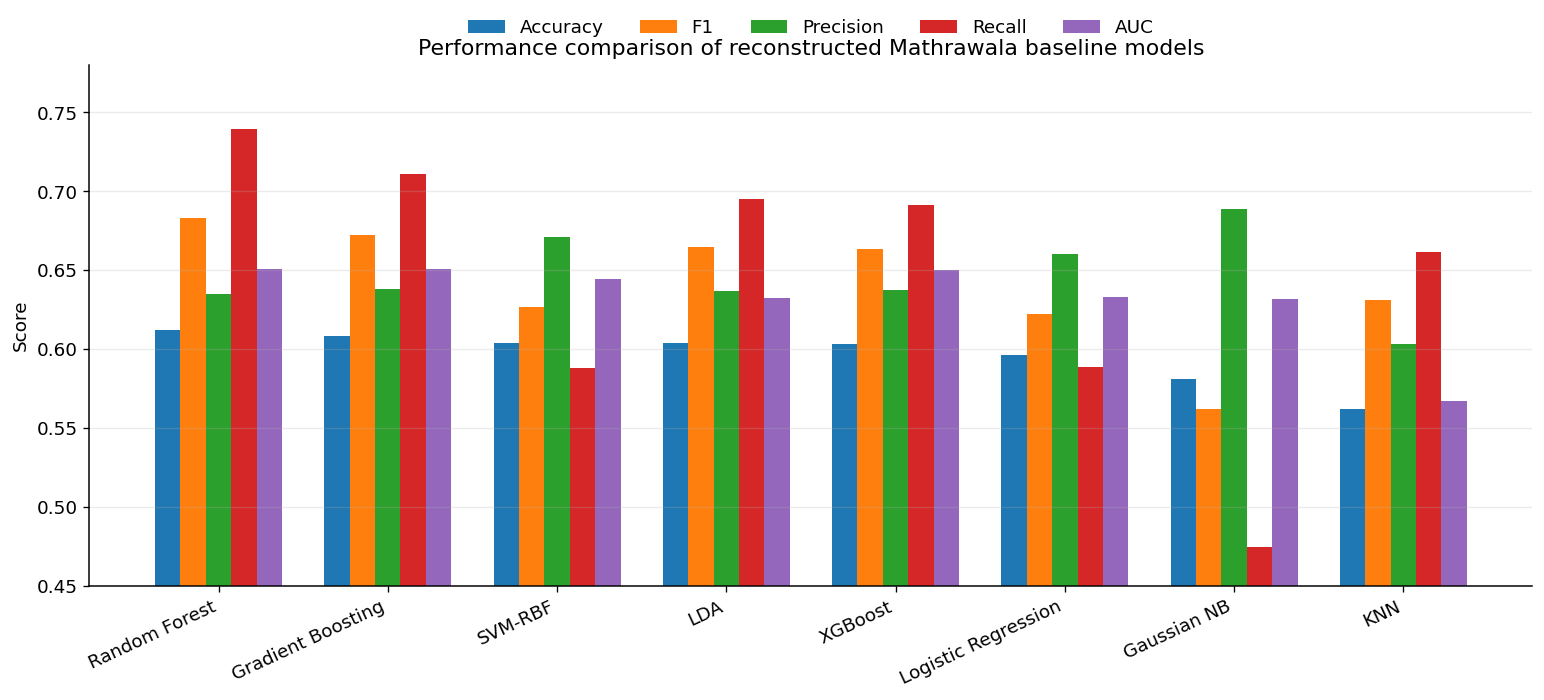

Missing prediction file for ROC: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/predictions_SVM_RBF_fast.csv
Missing prediction file for ROC: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/predictions_KNeighbors.csv
Missing prediction file for ROC: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/predictions_RandomForest.csv
Missing prediction file for ROC: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/predictions_XGBoost.csv
Missing prediction file for ROC: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/predictions_LogisticRegression.csv
Missing prediction file for ROC: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/predictions_LinearDiscriminant.csv
Missing prediction file for ROC: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/predictions_GaussianNB.csv
Missing prediction file for ROC: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/predictions_GradientBoosting.csv
ROC figure skipped: prediction files were not found.
Missing prediction file for PR: /content/drive/MyDrive/EXP8_

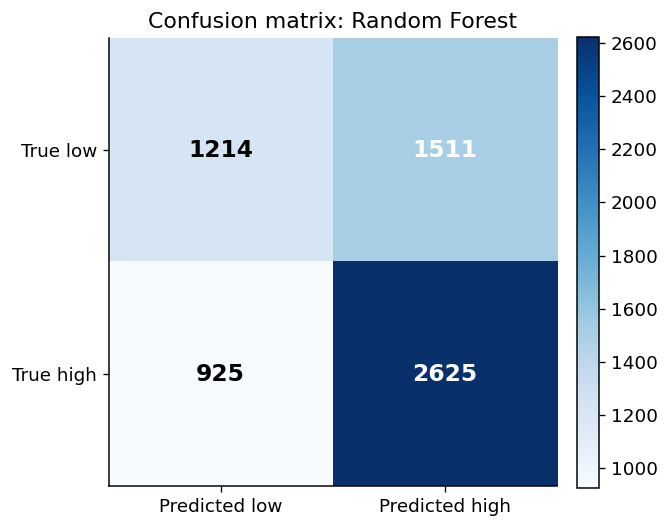

Saved: fig5_accuracy_f1_ci_loso_folds


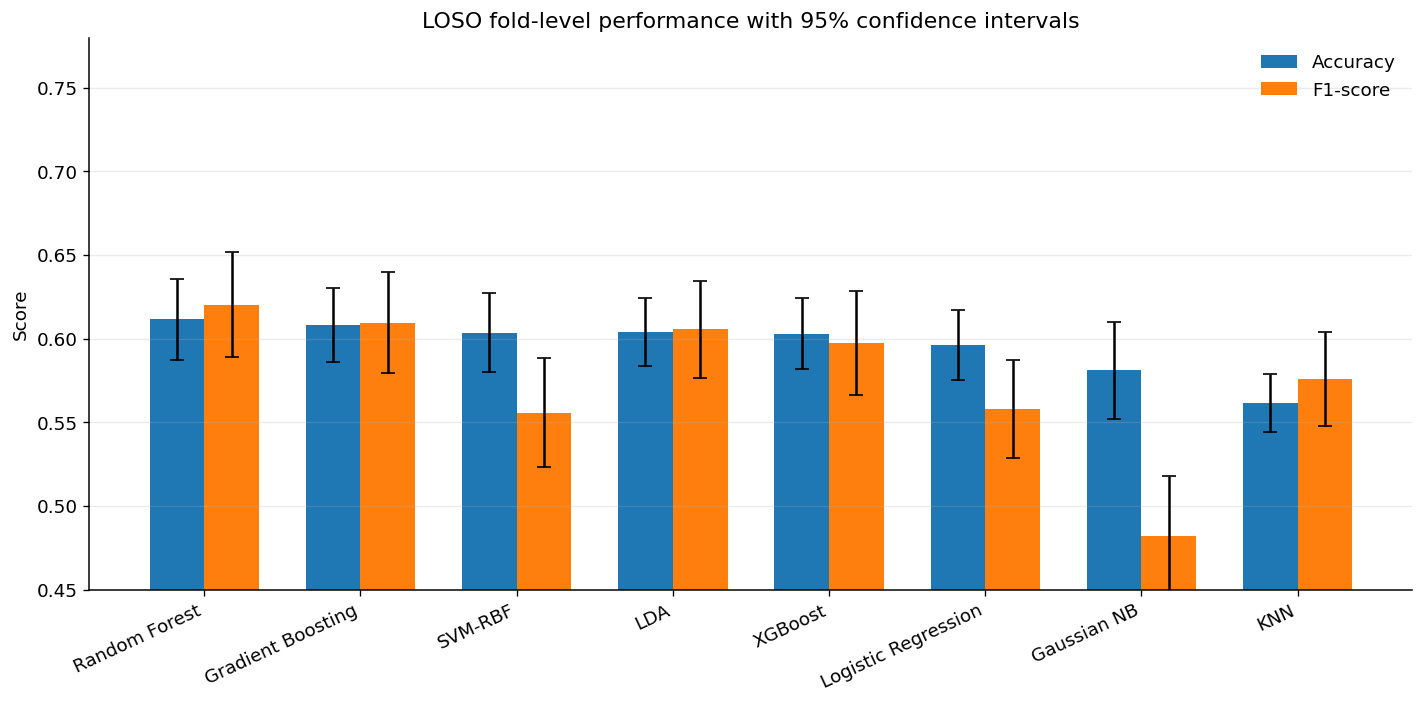

All publication figures saved in: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/publication_figures_mathrawala


In [ ]:
# Publication-style figures:
# 1) Grouped bar chart
# 2) ROC curves
# 3) Precision–Recall curves
# 4) Confusion matrix of best model
# 5) Accuracy/F1 with 95% CI across LOSO folds

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)

SAVE_DIR = "/content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE"
FIG_DIR = os.path.join(SAVE_DIR, "publication_figures_mathrawala")
os.makedirs(FIG_DIR, exist_ok=True)

MATHRAWALA_MODELS = [
    "SVM_RBF_fast",
    "KNeighbors",
    "RandomForest",
    "XGBoost",
    "LogisticRegression",
    "LinearDiscriminant",
    "GaussianNB",
    "GradientBoosting"
]

NAME_MAP = {
    "SVM_RBF_fast": "SVM-RBF",
    "KNeighbors": "KNN",
    "RandomForest": "Random Forest",
    "XGBoost": "XGBoost",
    "LogisticRegression": "Logistic Regression",
    "LinearDiscriminant": "LDA",
    "GaussianNB": "Gaussian NB",
    "GradientBoosting": "Gradient Boosting"
}

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.9,
    "grid.alpha": 0.25,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

def savefig(name):
    plt.savefig(os.path.join(FIG_DIR, f"{name}.png"), dpi=600, bbox_inches="tight")
    plt.savefig(os.path.join(FIG_DIR, f"{name}.pdf"), bbox_inches="tight")
    plt.savefig(os.path.join(FIG_DIR, f"{name}.svg"), bbox_inches="tight")
    print("Saved:", name)

# -----------------------------
# Load final results
# -----------------------------
rows = []
for model in MATHRAWALA_MODELS:
    path = os.path.join(SAVE_DIR, f"final_result_{model}.csv")
    if os.path.exists(path):
        rows.append(pd.read_csv(path))

results_df = pd.concat(rows, ignore_index=True)
results_df["Display"] = results_df["Model"].map(NAME_MAP)
results_df = results_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)

display(results_df)

# -----------------------------
# Fig 1: Grouped bar chart
# -----------------------------
metrics = ["Accuracy", "F1", "Precision", "Recall", "AUC"]
plot_df = results_df.copy()
x = np.arange(len(plot_df))
width = 0.15

plt.figure(figsize=(13, 6))
for i, metric in enumerate(metrics):
    plt.bar(x + (i - 2) * width, plot_df[metric], width, label=metric)

plt.xticks(x, plot_df["Display"], rotation=25, ha="right")
plt.ylabel("Score")
plt.ylim(0.45, 0.78)
plt.title("Performance comparison of reconstructed Mathrawala baseline models")
plt.grid(axis="y")
plt.legend(frameon=False, ncol=5, loc="upper center", bbox_to_anchor=(0.5, 1.12))
plt.tight_layout()
savefig("fig1_grouped_bar_all_metrics")
plt.show()

# -----------------------------
# Fig 2: ROC curves
# Needs saved per-sample prediction files.
# If you do not have them yet, use the modified evaluator below.
# Expected file format:
# predictions_<Model>.csv with columns: y_true, y_score
# -----------------------------
plt.figure(figsize=(7, 6))

found_roc = False
for model in MATHRAWALA_MODELS:
    pred_path = os.path.join(SAVE_DIR, f"predictions_{model}.csv")
    if not os.path.exists(pred_path):
        print("Missing prediction file for ROC:", pred_path)
        continue

    pred = pd.read_csv(pred_path)
    fpr, tpr, _ = roc_curve(pred["y_true"], pred["y_score"])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f"{NAME_MAP[model]} (AUC={roc_auc:.3f})")
    found_roc = True

if found_roc:
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("ROC curves of reconstructed Mathrawala baseline models")
    plt.grid(True)
    plt.legend(frameon=False, fontsize=9)
    plt.tight_layout()
    savefig("fig2_roc_curves_all_models")
    plt.show()
else:
    plt.close()
    print("ROC figure skipped: prediction files were not found.")

# -----------------------------
# Fig 3: Precision–Recall curves
# -----------------------------
plt.figure(figsize=(7, 6))

found_pr = False
for model in MATHRAWALA_MODELS:
    pred_path = os.path.join(SAVE_DIR, f"predictions_{model}.csv")
    if not os.path.exists(pred_path):
        print("Missing prediction file for PR:", pred_path)
        continue

    pred = pd.read_csv(pred_path)
    precision, recall, _ = precision_recall_curve(pred["y_true"], pred["y_score"])
    ap = average_precision_score(pred["y_true"], pred["y_score"])

    plt.plot(recall, precision, linewidth=2, label=f"{NAME_MAP[model]} (AP={ap:.3f})")
    found_pr = True

if found_pr:
    baseline = np.mean(pd.read_csv(os.path.join(SAVE_DIR, f"predictions_{MATHRAWALA_MODELS[0]}.csv"))["y_true"])
    plt.axhline(baseline, linestyle="--", linewidth=1, label=f"Class prior={baseline:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–recall curves of reconstructed Mathrawala baseline models")
    plt.grid(True)
    plt.legend(frameon=False, fontsize=9)
    plt.tight_layout()
    savefig("fig3_precision_recall_curves_all_models")
    plt.show()
else:
    plt.close()
    print("PR figure skipped: prediction files were not found.")

# -----------------------------
# Fig 4: Confusion matrix of best model
# -----------------------------
best_model = results_df.iloc[0]["Model"]
best_name = NAME_MAP[best_model]
cm_path = os.path.join(SAVE_DIR, f"confusion_{best_model}.csv")

cm_df = pd.read_csv(cm_path, index_col=0)
cm = cm_df.values

plt.figure(figsize=(5.5, 4.8))
im = plt.imshow(cm, cmap="Blues")
plt.xticks([0, 1], ["Predicted low", "Predicted high"])
plt.yticks([0, 1], ["True low", "True high"])
plt.title(f"Confusion matrix: {best_name}")

for i in range(2):
    for j in range(2):
        plt.text(
            j, i, f"{cm[i, j]}",
            ha="center", va="center",
            fontsize=14, fontweight="bold",
            color="white" if cm[i, j] > cm.max() / 2 else "black"
        )

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
savefig("fig4_best_model_confusion_matrix")
plt.show()

# -----------------------------
# Fig 5: Accuracy and F1 with 95% CI across LOSO folds
# -----------------------------
ci_rows = []

for model in MATHRAWALA_MODELS:
    fold_path = os.path.join(SAVE_DIR, f"partial_folds_{model}.csv")
    if not os.path.exists(fold_path):
        print("Missing fold file:", fold_path)
        continue

    fold_df = pd.read_csv(fold_path)

    for metric in ["accuracy", "f1"]:
        vals = fold_df[metric].dropna().values
        mean = np.mean(vals)
        se = np.std(vals, ddof=1) / np.sqrt(len(vals))
        ci = 1.96 * se

        ci_rows.append({
            "Model": NAME_MAP[model],
            "Metric": metric.upper() if metric == "f1" else "Accuracy",
            "Mean": mean,
            "CI95": ci
        })

ci_df = pd.DataFrame(ci_rows)

plt.figure(figsize=(12, 6))

models_order = results_df["Display"].tolist()
x = np.arange(len(models_order))
width = 0.35

acc = ci_df[ci_df["Metric"] == "Accuracy"].set_index("Model").loc[models_order]
f1 = ci_df[ci_df["Metric"] == "F1"].set_index("Model").loc[models_order]

plt.bar(x - width/2, acc["Mean"], width, yerr=acc["CI95"], capsize=4, label="Accuracy")
plt.bar(x + width/2, f1["Mean"], width, yerr=f1["CI95"], capsize=4, label="F1-score")

plt.xticks(x, models_order, rotation=25, ha="right")
plt.ylabel("Score")
plt.ylim(0.45, 0.78)
plt.title("LOSO fold-level performance with 95% confidence intervals")
plt.grid(axis="y")
plt.legend(frameon=False)
plt.tight_layout()
savefig("fig5_accuracy_f1_ci_loso_folds")
plt.show()

ci_df.to_csv(os.path.join(FIG_DIR, "accuracy_f1_ci_table.csv"), index=False)
results_df.to_csv(os.path.join(FIG_DIR, "mathrawala_publication_results_table.csv"), index=False)

print("All publication figures saved in:", FIG_DIR)

In [ ]:
# Run ONE model at a time to create predictions_<Model>.csv
# RandomForest already done, so start with XGBoost or any remaining model.

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

remaining_models = {
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ),

    "LinearDiscriminant": LinearDiscriminantAnalysis(),

    "GaussianNB": GaussianNB(),

    "KNeighbors": KNeighborsClassifier(n_neighbors=5),

    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ),

    "SVM_RBF_fast": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=False,
        class_weight="balanced",
        cache_size=2000
    ),

    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

# Choose only ONE model name here each time
MODEL_TO_RUN = "XGBoost"

clf = remaining_models[MODEL_TO_RUN]

evaluate_one_model_with_predictions(
    MODEL_TO_RUN,
    clf,
    X, y, groups,
    SAVE_DIR
)

XGBoost: 100%|██████████| 223/223 [33:08<00:00,  8.92s/it]

Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/predictions_XGBoost.csv


In [ ]:
# Run ONE model at a time to create predictions_<Model>.csv
# RandomForest already done, so start with XGBoost or any remaining model.

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

remaining_models = {
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ),

    "LinearDiscriminant": LinearDiscriminantAnalysis(),

    "GaussianNB": GaussianNB(),

    "KNeighbors": KNeighborsClassifier(n_neighbors=5),

    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ),

    "SVM_RBF_fast": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=False,
        class_weight="balanced",
        cache_size=2000
    ),

    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

# Choose only ONE model name here each time
MODEL_TO_RUN = "LinearDiscriminant"

clf = remaining_models[MODEL_TO_RUN]

evaluate_one_model_with_predictions(
    MODEL_TO_RUN,
    clf,
    X, y, groups,
    SAVE_DIR
)

LinearDiscriminant: 100%|██████████| 223/223 [03:07<00:00,  1.19it/s]

Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/predictions_LinearDiscriminant.csv


In [ ]:
# Run ONE model at a time to create predictions_<Model>.csv
# RandomForest already done, so start with XGBoost or any remaining model.

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

remaining_models = {
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ),

    "LinearDiscriminant": LinearDiscriminantAnalysis(),

    "GaussianNB": GaussianNB(),

    "KNeighbors": KNeighborsClassifier(n_neighbors=5),

    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ),

    "SVM_RBF_fast": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=False,
        class_weight="balanced",
        cache_size=2000
    ),

    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

# Choose only ONE model name here each time
MODEL_TO_RUN = "GaussianNB"

clf = remaining_models[MODEL_TO_RUN]

evaluate_one_model_with_predictions(
    MODEL_TO_RUN,
    clf,
    X, y, groups,
    SAVE_DIR
)

GaussianNB: 100%|██████████| 223/223 [00:35<00:00,  6.30it/s]

Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/predictions_GaussianNB.csv


In [ ]:
# Run ONE model at a time to create predictions_<Model>.csv
# RandomForest already done, so start with XGBoost or any remaining model.

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

remaining_models = {
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ),

    "LinearDiscriminant": LinearDiscriminantAnalysis(),

    "GaussianNB": GaussianNB(),

    "KNeighbors": KNeighborsClassifier(n_neighbors=5),

    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ),

    "SVM_RBF_fast": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=False,
        class_weight="balanced",
        cache_size=2000
    ),

    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

# Choose only ONE model name here each time
MODEL_TO_RUN = "KNeighbors"

clf = remaining_models[MODEL_TO_RUN]

evaluate_one_model_with_predictions(
    MODEL_TO_RUN,
    clf,
    X, y, groups,
    SAVE_DIR
)

NameError: name 'evaluate_one_model_with_predictions' is not defined

In [ ]:
# Run ONE model at a time to create predictions_<Model>.csv
# RandomForest already done, so start with XGBoost or any remaining model.

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

remaining_models = {
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ),

    "LinearDiscriminant": LinearDiscriminantAnalysis(),

    "GaussianNB": GaussianNB(),

    "KNeighbors": KNeighborsClassifier(n_neighbors=5),

    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ),

    "SVM_RBF_fast": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=False,
        class_weight="balanced",
        cache_size=2000
    ),

    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

# Choose only ONE model name here each time
MODEL_TO_RUN = "LogisticRegression"

clf = remaining_models[MODEL_TO_RUN]

evaluate_one_model_with_predictions(
    MODEL_TO_RUN,
    clf,
    X, y, groups,
    SAVE_DIR
)

In [ ]:
# Run ONE model at a time to create predictions_<Model>.csv
# RandomForest already done, so start with XGBoost or any remaining model.

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

remaining_models = {
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ),

    "LinearDiscriminant": LinearDiscriminantAnalysis(),

    "GaussianNB": GaussianNB(),

    "KNeighbors": KNeighborsClassifier(n_neighbors=5),

    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ),

    "SVM_RBF_fast": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=False,
        class_weight="balanced",
        cache_size=2000
    ),

    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

# Choose only ONE model name here each time
MODEL_TO_RUN = "SVM_RBF_fast"

clf = remaining_models[MODEL_TO_RUN]

evaluate_one_model_with_predictions(
    MODEL_TO_RUN,
    clf,
    X, y, groups,
    SAVE_DIR
)

In [ ]:
import os
import time
import numpy as np
import pandas as pd

from tqdm import tqdm

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
import os, time
import numpy as np
import pandas as pd
from tqdm import tqdm

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut

def evaluate_one_model_with_predictions(name, clf, X, y, groups, save_dir):
    logo = LeaveOneGroupOut()
    pred_rows = []

    pred_path = os.path.join(save_dir, f"predictions_{name}.csv")

    for fold, (train_idx, test_idx) in enumerate(
        tqdm(logo.split(X, y, groups), total=len(np.unique(groups)), desc=name), 1
    ):
        test_subject = groups[test_idx][0]

        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler()),
            ("clf", clf)
        ])

        Xtr, Xte = X[train_idx], X[test_idx]
        ytr, yte = y[train_idx].astype(int), y[test_idx].astype(int)

        pipe.fit(Xtr, ytr)
        y_pred = pipe.predict(Xte)

        if hasattr(pipe.named_steps["clf"], "predict_proba"):
            y_score = pipe.predict_proba(Xte)[:, 1]
        elif hasattr(pipe.named_steps["clf"], "decision_function"):
            y_score = pipe.decision_function(Xte)
        else:
            y_score = y_pred.astype(float)

        for i in range(len(test_idx)):
            pred_rows.append({
                "fold": fold,
                "subject": test_subject,
                "y_true": int(yte[i]),
                "y_pred": int(y_pred[i]),
                "y_score": float(y_score[i])
            })

        # save after every fold
        pd.DataFrame(pred_rows).to_csv(pred_path, index=False)

    print("Saved:", pred_path)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

evaluate_one_model_with_predictions(
    "GradientBoosting",
    gb,
    X, y, groups,
    SAVE_DIR
)

GradientBoosting: 100%|██████████| 223/223 [7:06:23<00:00, 114.72s/it]

Saved: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/predictions_GradientBoosting.csv


In [ ]:
import os
import glob
import pandas as pd

SAVE_DIR = "/content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE"

prediction_files = sorted(glob.glob(os.path.join(SAVE_DIR, "predictions_*.csv")))

print("=" * 80)
print(f"Found {len(prediction_files)} prediction files\n")

for f in prediction_files:
    df = pd.read_csv(f)
    print(f"{os.path.basename(f):40s}  {df.shape}")

print("=" * 80)

Found 8 prediction files

predictions_GaussianNB.csv                (6275, 5)
predictions_GradientBoosting.csv          (6275, 5)
predictions_KNeighbors.csv                (6275, 5)
predictions_LinearDiscriminant.csv        (6275, 5)
predictions_LogisticRegression.csv        (6275, 5)
predictions_RandomForest.csv              (6275, 5)
predictions_SVM_RBF_fast.csv              (6275, 5)
predictions_XGBoost.csv                   (6275, 5)


,Model,Accuracy,F1,Precision,Recall,AUC,Mean_Fold_Accuracy,Std_Fold_Accuracy,Mean_Inference_ms_per_epoch,Display
0,RandomForest,0.611793,0.683060,0.634671,0.739437,0.651004,0.611521,0.183453,2.322789,Random Forest
1,GradientBoosting,0.608287,0.672529,0.638018,0.710986,0.650836,0.608123,0.168163,0.062485,Gradient Boosting
2,SVM_RBF_fast,0.603825,0.626727,0.671061,0.587887,0.644593,0.603678,0.179576,2.868618,SVM-RBF
3,LinearDiscriminant,0.603506,0.664871,0.637068,0.695211,0.632281,0.604126,0.154286,0.057015,LDA
4,XGBoost,0.603028,0.663242,0.637640,0.690986,0.650118,0.603121,0.162852,0.113415,XGBoost
5,LogisticRegression,0.596016,0.622487,0.660348,0.588732,0.632732,0.596396,0.159498,0.114627,Logistic Regression
6,GaussianNB,0.581195,0.561708,0.688471,0.474366,0.631655,0.581095,0.219533,0.052320,Gaussian NB
7,KNeighbors,0.562072,0.630844,0.602979,0.661408,0.567053,0.561599,0.129946,0.488952,KNN


Saved: fig1_grouped_bar_all_metrics


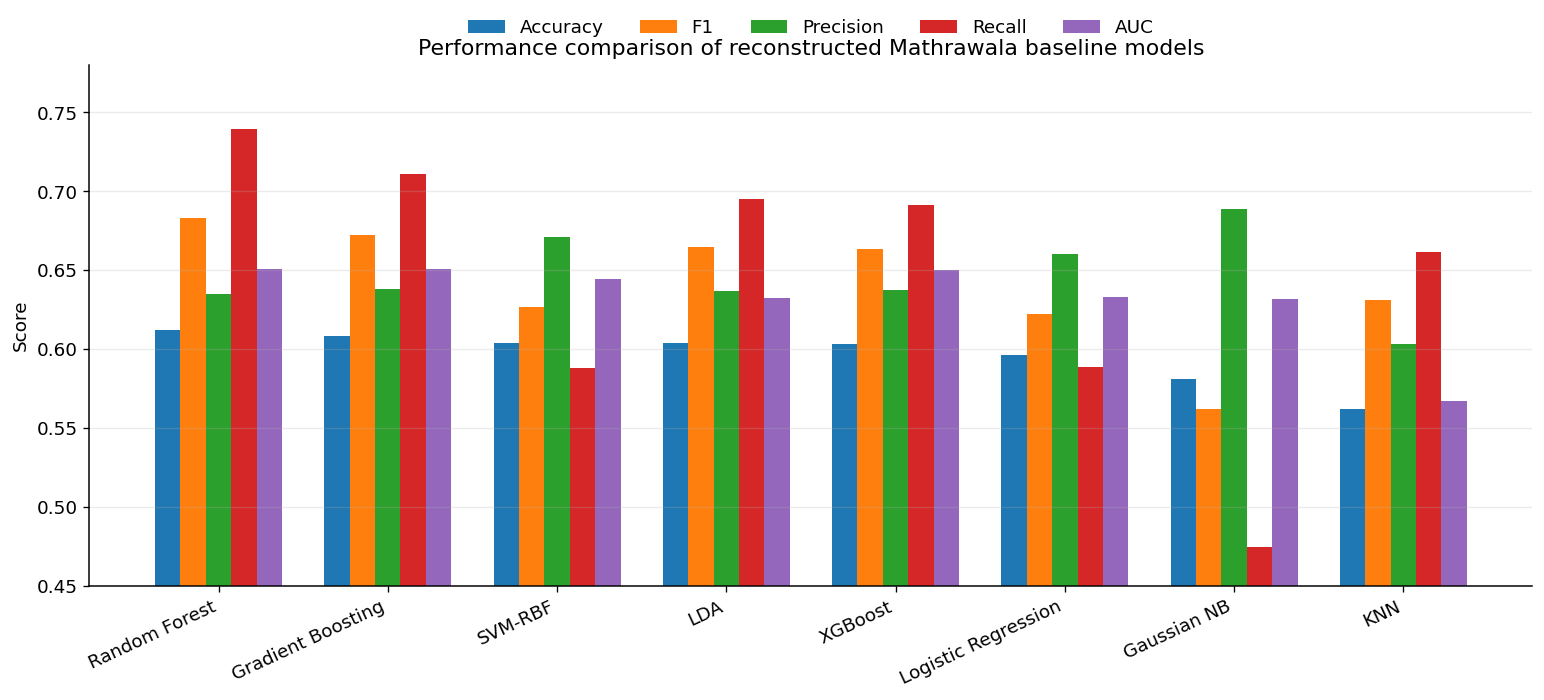

Saved: fig2_roc_curves_all_models


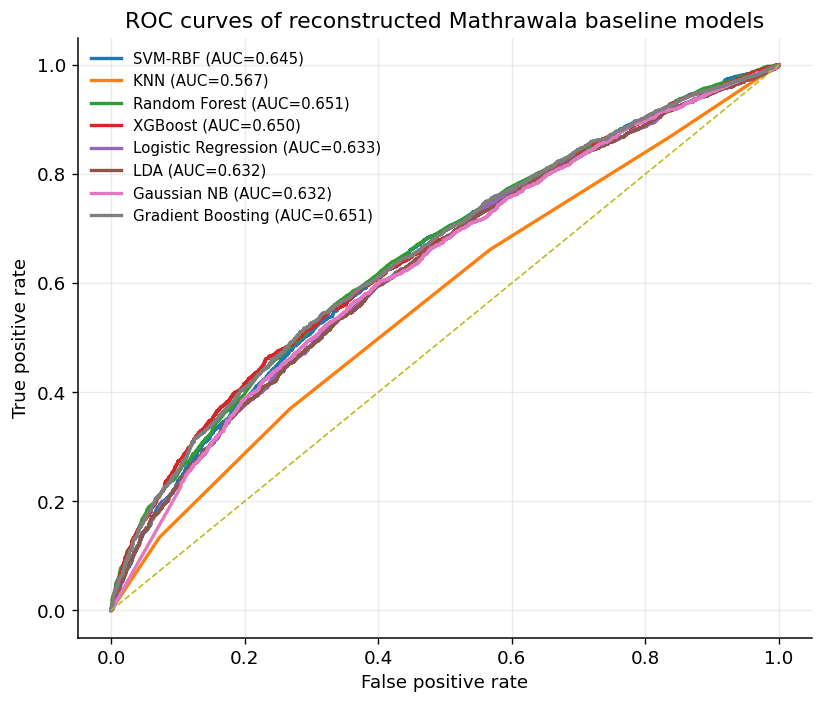

Saved: fig3_precision_recall_curves_all_models


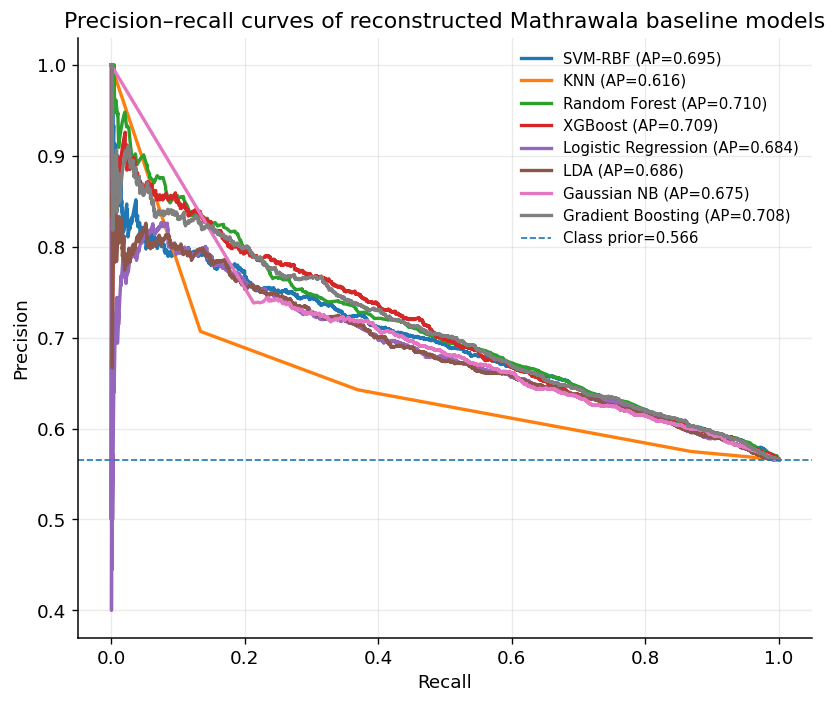

Saved: fig4_best_model_confusion_matrix


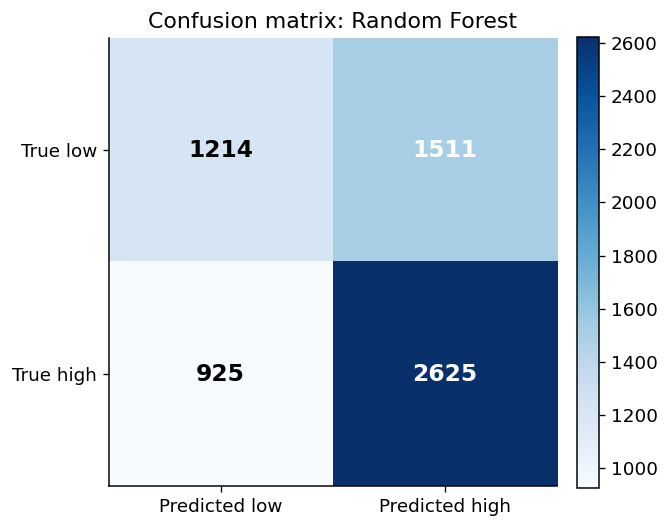

Saved: fig5_accuracy_f1_ci_loso_folds


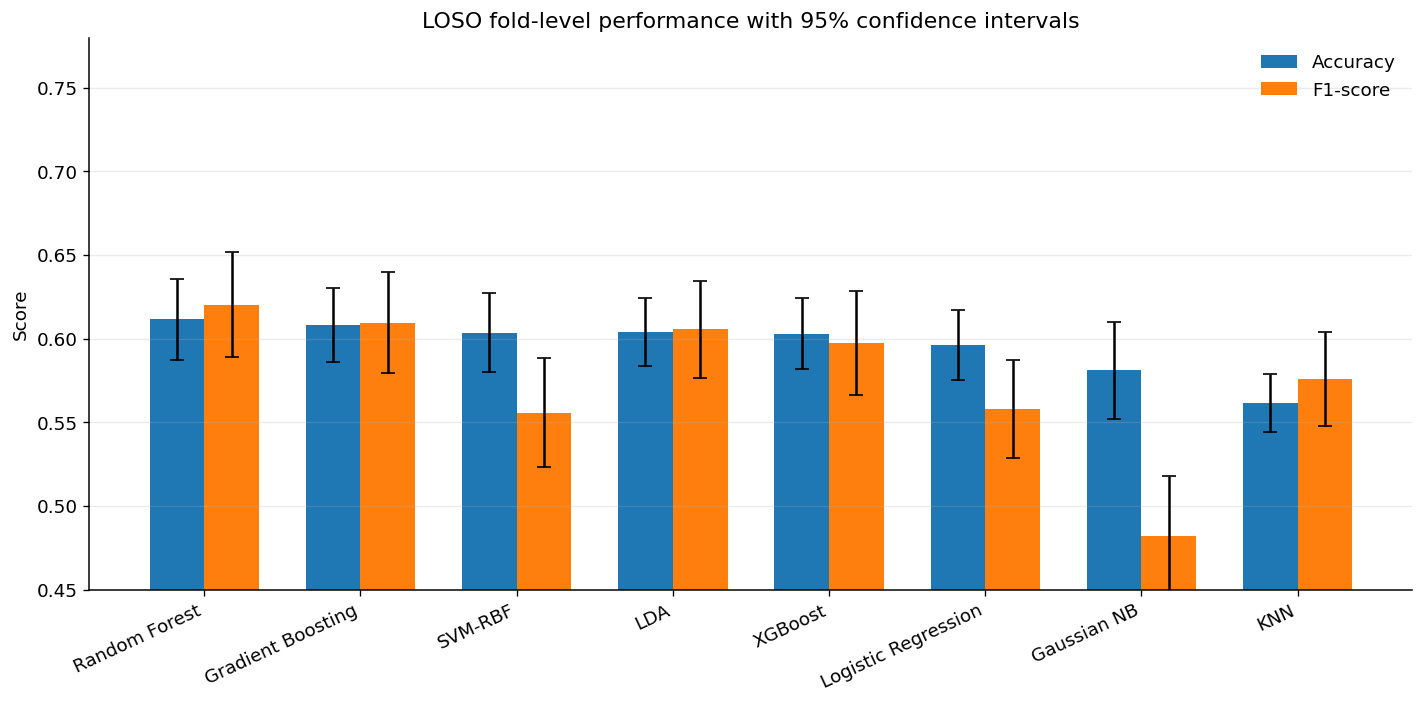

All publication figures saved in: /content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE/publication_figures_mathrawala


In [ ]:
# Publication-style figures:
# 1) Grouped bar chart
# 2) ROC curves
# 3) Precision–Recall curves
# 4) Confusion matrix of best model
# 5) Accuracy/F1 with 95% CI across LOSO folds

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)

SAVE_DIR = "/content/drive/MyDrive/EXP8_MATHRAWALA_BASELINE"
FIG_DIR = os.path.join(SAVE_DIR, "publication_figures_mathrawala")
os.makedirs(FIG_DIR, exist_ok=True)

MATHRAWALA_MODELS = [
    "SVM_RBF_fast",
    "KNeighbors",
    "RandomForest",
    "XGBoost",
    "LogisticRegression",
    "LinearDiscriminant",
    "GaussianNB",
    "GradientBoosting"
]

NAME_MAP = {
    "SVM_RBF_fast": "SVM-RBF",
    "KNeighbors": "KNN",
    "RandomForest": "Random Forest",
    "XGBoost": "XGBoost",
    "LogisticRegression": "Logistic Regression",
    "LinearDiscriminant": "LDA",
    "GaussianNB": "Gaussian NB",
    "GradientBoosting": "Gradient Boosting"
}

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.9,
    "grid.alpha": 0.25,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

def savefig(name):
    plt.savefig(os.path.join(FIG_DIR, f"{name}.png"), dpi=600, bbox_inches="tight")
    plt.savefig(os.path.join(FIG_DIR, f"{name}.pdf"), bbox_inches="tight")
    plt.savefig(os.path.join(FIG_DIR, f"{name}.svg"), bbox_inches="tight")
    print("Saved:", name)

# -----------------------------
# Load final results
# -----------------------------
rows = []
for model in MATHRAWALA_MODELS:
    path = os.path.join(SAVE_DIR, f"final_result_{model}.csv")
    if os.path.exists(path):
        rows.append(pd.read_csv(path))

results_df = pd.concat(rows, ignore_index=True)
results_df["Display"] = results_df["Model"].map(NAME_MAP)
results_df = results_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)

display(results_df)

# -----------------------------
# Fig 1: Grouped bar chart
# -----------------------------
metrics = ["Accuracy", "F1", "Precision", "Recall", "AUC"]
plot_df = results_df.copy()
x = np.arange(len(plot_df))
width = 0.15

plt.figure(figsize=(13, 6))
for i, metric in enumerate(metrics):
    plt.bar(x + (i - 2) * width, plot_df[metric], width, label=metric)

plt.xticks(x, plot_df["Display"], rotation=25, ha="right")
plt.ylabel("Score")
plt.ylim(0.45, 0.78)
plt.title("Performance comparison of reconstructed Mathrawala baseline models")
plt.grid(axis="y")
plt.legend(frameon=False, ncol=5, loc="upper center", bbox_to_anchor=(0.5, 1.12))
plt.tight_layout()
savefig("fig1_grouped_bar_all_metrics")
plt.show()

# -----------------------------
# Fig 2: ROC curves
# Needs saved per-sample prediction files.
# If you do not have them yet, use the modified evaluator below.
# Expected file format:
# predictions_<Model>.csv with columns: y_true, y_score
# -----------------------------
plt.figure(figsize=(7, 6))

found_roc = False
for model in MATHRAWALA_MODELS:
    pred_path = os.path.join(SAVE_DIR, f"predictions_{model}.csv")
    if not os.path.exists(pred_path):
        print("Missing prediction file for ROC:", pred_path)
        continue

    pred = pd.read_csv(pred_path)
    fpr, tpr, _ = roc_curve(pred["y_true"], pred["y_score"])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f"{NAME_MAP[model]} (AUC={roc_auc:.3f})")
    found_roc = True

if found_roc:
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("ROC curves of reconstructed Mathrawala baseline models")
    plt.grid(True)
    plt.legend(frameon=False, fontsize=9)
    plt.tight_layout()
    savefig("fig2_roc_curves_all_models")
    plt.show()
else:
    plt.close()
    print("ROC figure skipped: prediction files were not found.")

# -----------------------------
# Fig 3: Precision–Recall curves
# -----------------------------
plt.figure(figsize=(7, 6))

found_pr = False
for model in MATHRAWALA_MODELS:
    pred_path = os.path.join(SAVE_DIR, f"predictions_{model}.csv")
    if not os.path.exists(pred_path):
        print("Missing prediction file for PR:", pred_path)
        continue

    pred = pd.read_csv(pred_path)
    precision, recall, _ = precision_recall_curve(pred["y_true"], pred["y_score"])
    ap = average_precision_score(pred["y_true"], pred["y_score"])

    plt.plot(recall, precision, linewidth=2, label=f"{NAME_MAP[model]} (AP={ap:.3f})")
    found_pr = True

if found_pr:
    baseline = np.mean(pd.read_csv(os.path.join(SAVE_DIR, f"predictions_{MATHRAWALA_MODELS[0]}.csv"))["y_true"])
    plt.axhline(baseline, linestyle="--", linewidth=1, label=f"Class prior={baseline:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–recall curves of reconstructed Mathrawala baseline models")
    plt.grid(True)
    plt.legend(frameon=False, fontsize=9)
    plt.tight_layout()
    savefig("fig3_precision_recall_curves_all_models")
    plt.show()
else:
    plt.close()
    print("PR figure skipped: prediction files were not found.")

# -----------------------------
# Fig 4: Confusion matrix of best model
# -----------------------------
best_model = results_df.iloc[0]["Model"]
best_name = NAME_MAP[best_model]
cm_path = os.path.join(SAVE_DIR, f"confusion_{best_model}.csv")

cm_df = pd.read_csv(cm_path, index_col=0)
cm = cm_df.values

plt.figure(figsize=(5.5, 4.8))
im = plt.imshow(cm, cmap="Blues")
plt.xticks([0, 1], ["Predicted low", "Predicted high"])
plt.yticks([0, 1], ["True low", "True high"])
plt.title(f"Confusion matrix: {best_name}")

for i in range(2):
    for j in range(2):
        plt.text(
            j, i, f"{cm[i, j]}",
            ha="center", va="center",
            fontsize=14, fontweight="bold",
            color="white" if cm[i, j] > cm.max() / 2 else "black"
        )

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
savefig("fig4_best_model_confusion_matrix")
plt.show()

# -----------------------------
# Fig 5: Accuracy and F1 with 95% CI across LOSO folds
# -----------------------------
ci_rows = []

for model in MATHRAWALA_MODELS:
    fold_path = os.path.join(SAVE_DIR, f"partial_folds_{model}.csv")
    if not os.path.exists(fold_path):
        print("Missing fold file:", fold_path)
        continue

    fold_df = pd.read_csv(fold_path)

    for metric in ["accuracy", "f1"]:
        vals = fold_df[metric].dropna().values
        mean = np.mean(vals)
        se = np.std(vals, ddof=1) / np.sqrt(len(vals))
        ci = 1.96 * se

        ci_rows.append({
            "Model": NAME_MAP[model],
            "Metric": metric.upper() if metric == "f1" else "Accuracy",
            "Mean": mean,
            "CI95": ci
        })

ci_df = pd.DataFrame(ci_rows)

plt.figure(figsize=(12, 6))

models_order = results_df["Display"].tolist()
x = np.arange(len(models_order))
width = 0.35

acc = ci_df[ci_df["Metric"] == "Accuracy"].set_index("Model").loc[models_order]
f1 = ci_df[ci_df["Metric"] == "F1"].set_index("Model").loc[models_order]

plt.bar(x - width/2, acc["Mean"], width, yerr=acc["CI95"], capsize=4, label="Accuracy")
plt.bar(x + width/2, f1["Mean"], width, yerr=f1["CI95"], capsize=4, label="F1-score")

plt.xticks(x, models_order, rotation=25, ha="right")
plt.ylabel("Score")
plt.ylim(0.45, 0.78)
plt.title("LOSO fold-level performance with 95% confidence intervals")
plt.grid(axis="y")
plt.legend(frameon=False)
plt.tight_layout()
savefig("fig5_accuracy_f1_ci_loso_folds")
plt.show()

ci_df.to_csv(os.path.join(FIG_DIR, "accuracy_f1_ci_table.csv"), index=False)
results_df.to_csv(os.path.join(FIG_DIR, "mathrawala_publication_results_table.csv"), index=False)

print("All publication figures saved in:", FIG_DIR)